# Лекция 5: Нейросети, NLP и Computer Vision
## Как перестать бояться матана и полюбить Скайнет

Добро пожаловать в пятую лекцию! Сегодня мы сделаем перерыв в написании Docker-контейнеров, ковырянии PostgreSQL и настройке CI/CD пайплайнов. Вы уже умеете собирать данные, очищать их и строить базовые ML-модели вроде случайного леса или логистической регрессии. 

Но классический ML имеет свой потолок. Если вы попытаетесь скормить Random Forest сырую картинку размером 1080p или текст романа "Война и мир", ваш ноутбук скорее всего просто выйдет в окно от нехватки оперативной памяти, а точность будет на уровне случайного угадывания. 

Сегодня мы поговорим о **Глубоком обучении (Deep Learning)**. Мы разберем:
* Что такое нейросети на самом деле (спойлер: это просто много матриц).
* Как заставить модель читать тексты и понимать тональность ваших отзывов из парсеров (это прямо пойдет в ваши проекты *DataPulse*).
* Как заставить веб-камеру узнавать вас в лицо.

Готовьтесь. Сегодня будет много абстракций, немного линейной алгебры и очень много черного ящика.

---
## 1.1. Анатомия Скайнета: Из чего состоят нейросети?

Забудьте всё, что вам рассказывали журналисты, маркетологи и фантасты про "электронный мозг", "искусственное сознание" и "нейроны, подобные человеческим". Это всё красивая чушь для презентаций стартапов. 

Искусственная нейронная сеть — это просто **очень большая, сложная, составная математическая функция**, которая пытается аппроксимировать (подогнать) входные данные под желаемый результат с помощью бесконечного умножения матриц. Никакой магии. Только циничный матан.

### 🧠 Перцептрон: Клетка мозга курильщика

Базовый кирпичик любой нейросети — это искусственный нейрон (он же перцептрон). Его придумал Фрэнк Розенблатт еще в 1957 году, и с тех пор математическая суть почти не изменилась.

Представьте, что вы — это нейрон. И вам нужно принять бинарное решение: **"Идти ли сегодня на пару по Python?"**
На ваше решение влияют входные данные (фичи, $X$). Допустим, их три:
1. $x_1$: Количество часов, которые вы спали этой ночью (от 0 до 10).
2. $x_2$: Отмечает ли препод присутствие (0 — нет, 1 — да).
3. $x_3$: Температура на улице (в градусах Цельсия).

Но вы же не оцениваете эти факторы одинаково? Для вас они имеют разный приоритет. Этот приоритет в нейросетях называется **весом (Weight, $W$)**.
* Если вы панически боитесь отчисления, вес $w_2$ (за отмечание) будет огромным положительным числом (например, +50).
* Если вы ненавидите холод, то вес $w_3$ (за температуру) будет иметь значение в зависимости от вашей мерзлявости. Если на улице минус 30, это должно сильно давить на решение "остаться дома".
* А вес сна $w_1$ может быть, скажем, +5.

Внутри вас (нейрона) происходит простейшая операция: вы умножаете каждый фактор на его важность и складываете всё в одну кучу. Это называется **линейной комбинацией**:
$$z = w_1x_1 + w_2x_2 + w_3x_3$$

Но есть нюанс. У вас есть базовая, природная лень. Независимо от погоды, сна и препода, вам просто *не хочется* никуда идти. Эта базовая константа называется **смещением (Bias, $B$)**. В нашем случае это отрицательное число, которое тянет результат вниз.

Итоговая формула того, что происходит внутри одного нейрона:
$$z = \sum_{i=1}^{n} w_i x_i + b$$

Или, если мы пишем код на Python и используем NumPy (где входы и веса — это векторы), это выглядит как скалярное произведение (Dot Product): `z = np.dot(W, X) + b`.

### ⚡ Функции активации: Добавляем искру жизни

Окей, нейрон посчитал $z$. Допустим, получилось число 42. Что это значит? Идти на пару или нет? Нам нужно как-то интерпретировать этот результат. Более того, если мы просто соединим тысячи таких линейных нейронов друг с другом в многослойную сеть, мы получим... ничто. 

Математический факт: **линейная комбинация линейных комбинаций — это всё еще линейная комбинация**. Сто слоев линейных нейронов можно математически схлопнуть в один единственный слой. Такая сеть никогда не сможет выучить сложные зависимости (например, отделить котов от собак на фото), потому что мир вокруг нас нелинейный.

Чтобы всё заработало, мы пропускаем результат $z$ через нелинейный фильтр — **функцию активации**. Это как фейсконтроль на входе в клуб: функция решает, какой сигнал пойдет дальше по сети, а какой будет заблокирован.

Какие они бывают:


1. **Step Function (Ступенчатая функция):**
   * *Как работает:* Если $z > 0$, выдает 1. Иначе выдает 0. 
   * *Почему мы ее больше не используем:* У нее нет градиента (производная везде равна нулю, кроме точки скачка). Нейросеть с такой активацией физически невозможно обучить градиентным спуском. Это мертвая технология из 60-х.

2. **Sigmoid (Сигмоида):**
   * *Как работает:* Сплющивает любое число (от минус бесконечности до плюс бесконечности) в плавный диапазон от 0 до 1.
   * *Формула:* $\sigma(x) = \frac{1}{1 + e^{-x}}$
   * *Плюсы:* Идеально подходит для выдачи вероятностей на самом последнем слое сети.
   * *Минусы (Затухание градиентов):* Если на вход сигмоиды приходит большое число (например, 100 или -100), ее производная становится почти нулевой. Нейрон становится "самоуверенным" и перестает учиться. Из-за этого глубокие сети с сигмоидами внутри обучаются чудовищно долго.

3. **ReLU (Rectified Linear Unit):**
   * *Как работает:* Самая тупая и самая гениальная функция. Пропускает всё, что больше нуля, без изменений. Всё отрицательное превращает в ноль.
   * *Формула:* $f(x) = \max(0, x)$
   * *Плюсы:* Считается за наносекунды (простое сравнение с нулем). Производная для положительных чисел равна 1 (никакого затухания градиентов!). Именно ReLU позволила обучать реально *глубокие* сети.
   * *Минусы (Dying ReLU):* Если на нейрон придет сильно отрицательное число, ReLU выдаст 0. Производная от нуля — ноль. Нейрон больше никогда не обновит свои веса, он "умирает" навсегда. В больших сетях до 40% нейронов могут быть мертвыми кусками памяти.

### 🎯 Функция потерь (Loss Function): Метрика наших страданий

Допустим, мы собрали сеть. Задали ей случайные веса (потому что мы пока не знаем правильных). Мы даем ей фотографию кота, а она выдает вероятности: "Это собака с вероятностью 80%, машина — 15%, кот — 5%". 

Нейросеть катастрофически неправа. Нам нужна математическая формула, которая посмотрит на предсказание, посмотрит на правильный ответ (ground truth) и выдаст одно число — уровень того, насколько сеть "накосячила". Это и есть **Loss (потеря)**.

Цель всей жизни нейросети — сделать Loss как можно ближе к нулю.

* **Для задач регрессии (предсказание числа, например, цены квартиры):** Мы используем **MSE (Mean Squared Error)**. Мы берем разницу между предсказанием и фактом, возводим в квадрат (чтобы убрать минусы и сильнее наказать за большие ошибки) и усредняем.
* **Для задач классификации (кот/собака/гусь):** Мы используем **Cross-Entropy Loss (Перекрестная энтропия)**. Она работает с логарифмами вероятностей. Если сеть была уверена на 99%, что это собака, а это оказался кот — логарифмический штраф будет просто гигантским. Она наказывает за ложную самоуверенность.

---
## 1.2. Обучение без слез: Как заставить эту кучу матриц поумнеть?

Итак, мы умеем прогонять данные через сеть от начала до конца (это называется **Forward Pass**). На выходе мы получили огромное значение Loss. Сеть глупа, как пробка. Как нам обновить миллионы весов $W$ и смещений $B$ в каждом слое, чтобы при следующей попытке Loss стал чуть-чуть меньше?

Здесь на сцену выходит главный дуэт машинного обучения: **Градиентный спуск** и **Backpropagation**.

### ⛰️ Градиентный спуск: Пьяный альпинист в тумане


Представьте себе ландшафт функции потерь (Loss Surface). Это бесконечно огромная гора с впадинами, холмами и ущельями. Каждая точка на этой горе — это определенная комбинация всех весов нашей нейросети. Высота в этой точке — это значение Loss. Наша задача — спуститься в самую нижнюю точку долины (Глобальный минимум), где ошибка минимальна.

Проблема в том, что у нас не 3D-гора. У современных сетей (как GPT-4) триллионы весов. Это гора в триллионно-мерном пространстве. Мы не можем "посмотреть" на нее сверху. 

Мы — слепой, слегка подвыпивший альпинист, стоящий где-то на склоне. Вокруг густой туман. Что мы делаем?
1. Мы ставим ногу и щупаем землю вокруг себя.
2. Мы понимаем, в какую сторону склон идет вверх (находим вектор анти-градиента).
3. Мы делаем шаг ровно в *противоположную* сторону — то есть вниз.
4. Повторяем это тысячи раз, пока не перестанем спускаться (достигнем дна).

**Градиент** в математике — это вектор частных производных. Он показывает направление самого крутого подъема. Мы берем наши веса и вычитаем из них градиент, умноженный на шаг.

Размер этого шага называется **Learning Rate ($\alpha$)** или скорость обучения. Это самый важный гиперпараметр в ML:
* **Слишком маленький Learning Rate:** Наш альпинист делает шаги размером с муравья. Мы будем спускаться в долину годы (сеть будет учиться бесконечно долго).
* **Слишком большой Learning Rate:** Альпинист надел сапоги-скороходы и прыгает на километры. Он перепрыгнет долину, приземлится на соседний склон выше, отскочит еще выше, и в итоге улетит в стратосферу (Loss взорвется, и в коде вы увидите ошибки `NaN` - Not a Number).

### 🔄 Батчи (Batches): Сколько данных показывать за раз?

У нас есть миллион картинок с котами. Как часто альпинисту стоит осматриваться и делать шаг?

1. **Full-batch (Полный спуск):** Мы прогоняем через сеть весь миллион картинок, считаем средний Loss и делаем один супер-точный шаг. Звучит надежно, но ваша видеокарта сгорит от нехватки памяти, а один шаг будет длиться неделю.
2. **Stochastic Gradient Descent (SGD, по одной картинке):** Мы берем одну случайную картинку, смотрим Loss, делаем шаг. Берем вторую — делаем шаг. Это очень быстро, но альпиниста будет швырять из стороны в сторону, как в центрифуге, потому что одна конкретная картинка может быть выбросом (например, лысый кот сфинкс, похожий на сырую курицу).
3. **Mini-batch (Мини-батчи):** Золотая середина. Мы берем пачку данных (например, 32 или 64 картинки), считаем средний Loss по ним и делаем шаг. И память не перегружена, и направление шага достаточно усредненное и адекватное. Именно так сейчас обучают 100% нейросетей.

### 🔙 Backpropagation: Великая раздача вины (Chain Rule)

Остался последний, самый сложный вопрос. Мы находимся в конце нейросети. Мы посчитали Loss. Как нам узнать, насколько сильно виноват в этой ошибке конкретный вес $w_{42}$ где-то в первом скрытом слое? 

Здесь работает алгоритм **Обратного распространения ошибки (Backpropagation)**. По сути, это применение правила дифференцирования сложной функции (Chain Rule) из первого курса вышки.

Представьте себе корпоративную иерархию:
1. Нейросеть выдает плохой результат. Клиент (Loss Function) в бешенстве звонит Генеральному директору (Выходной слой).
2. Генеральный директор понимает, что косяк есть. Он оценивает масштаб трагедии (считает производную) и вызывает к себе Менеджеров (Предпоследний слой).
3. "Так, Менеджер А, ты дал мне плохой отчет, ты виноват на 80%. Менеджер Б, твой отчет норм, к тебе нет вопросов". Директор передает вину (градиенты) вниз.
4. Менеджер А бежит к своим Тимлидам (Слой еще глубже) и распределяет свою часть вины между ними, пропорционально их вкладу (весам).
5. И так по цепочке вина (градиенты) доходит до самых младших Джунов (Первый слой сети).

Математически мы просто берем производную Loss по выходу сети, умножаем ее на производную выхода по предпоследнему слою, умножаем на производную предпоследнего по пред-предпоследнему... и так до самого входа.

В 1990-х годах Data Scientist'ы должны были выводить эти гигантские формулы производных на бумаге и кодить их на C++ руками. Ошибка в одном знаке минус стоила месяцев работы. 

Сегодня вам это делать **не нужно**. Библиотеки вроде PyTorch и TensorFlow строят внутри себя "вычислительный граф" и считают все производные (Backprop) автоматически с помощью магии под названием `Autograd`. Вы просто говорите `loss.backward()`, и все градиенты по всей сети считаются сами за миллисекунды. 

Именно эту магию мы сейчас и будем писать в коде.

---
## 1.3. Знакомство с PyTorch: Ваша новая любимая игрушка

Хватит теории. Давайте писать код. 
Раньше люди писали нейросети на чистом C++ или использовали суровый TensorFlow 1.0, где код был похож на заклинания вызова демонов. Сегодня индустриальным стандартом для исследований и разработки стал **PyTorch** от Meta (запрещена, осуждаем и всё такое).

Почему PyTorch? 
1. Он "Pythonic" — код выглядит и ведет себя как обычный Python.
2. Он поддерживает динамические вычислительные графы (можно дебажить прямо во время работы, в отличие от старых фреймворков).
3. Он умеет считать градиенты за вас.

Давайте импортируем эту махину.

*(Если у вас локально не стоит PyTorch, самое время сделать `pip install torch`)*

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import numpy as np

# Проверяем версию, чтобы убедиться, что мы живем в настоящем
print(f"Установленная версия PyTorch: {torch.__version__}")

Установленная версия PyTorch: 2.10.0+cu128


### 🧱 Тензоры: Матрешки из чисел

В классическом ML (в Pandas и Scikit-Learn) мы работали с DataFrame и массивами NumPy. В Deep Learning мы работаем с **Тензорами (Tensors)**.

Что такое тензор? Грубо говоря, это тот же самый массив NumPy, но на стероидах. 



* **Скаляр (0D тензор):** Просто одно число. Например, температура на улице (5) или ваш текущий Loss.
* **Вектор (1D тензор):** Массив чисел. Например, ряд в таблице базы данных вашего *DataPulse* (зарплата, опыт, возраст).
* **Матрица (2D тензор):** Таблица чисел. Например, черно-белая картинка (высота $\times$ ширина) или весь ваш датасет целиком (строки $\times$ столбцы).
* **3D Тензор:** Куб из чисел. Например, цветная картинка (каналы RGB $\times$ высота $\times$ ширина).
* **4D Тензор:** Массив из 3D-тензоров. Это и есть **Батч (Batch)** цветных картинок, который мы скармливаем видеокарте!

Давайте создадим пару тензоров и посмотрим, почему студенты по всему миру плачут по ночам из-за ошибки `RuntimeError: size mismatch`.

In [3]:
# 1. Создание тензоров из обычных списков Python
scalar = torch.tensor(42)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1, 2], [3, 4], [5, 6]])

print(f"Скаляр: {scalar}, Размерность (Shape): {scalar.shape}")
print(f"Вектор: {vector}, Размерность (Shape): {vector.shape}")
print(f"Матрица:\n{matrix}\nРазмерность (Shape): {matrix.shape}")

# 2. Связь с NumPy (они лучшие друзья)
np_array = np.array([10, 20, 30])
tensor_from_np = torch.from_numpy(np_array)
print(f"\nИз NumPy в PyTorch: {tensor_from_np}")

# 3. Случайные тензоры (очень важно для инициализации весов нейросети!)
# Создадим "игрушечный" батч из 32 цветных картинок размером 64x64 пикселя
# Формат PyTorch: [Batch_size, Channels, Height, Width]
dummy_images = torch.rand(size=(32, 3, 64, 64))
print(f"\nРазмерность фейкового батча картинок: {dummy_images.shape}")

Скаляр: 42, Размерность (Shape): torch.Size([])
Вектор: tensor([1., 2., 3.]), Размерность (Shape): torch.Size([3])
Матрица:
tensor([[1, 2],
        [3, 4],
        [5, 6]])
Размерность (Shape): torch.Size([3, 2])

Из NumPy в PyTorch: tensor([10, 20, 30])

Размерность фейкового батча картинок: torch.Size([32, 3, 64, 64])


### 🔄 Изменение формы (Reshape / View)

Самая частая операция в Deep Learning — это сплющивание и изменение размерности. Например, чтобы передать картинку в линейный слой нейросети, её нужно "вытянуть" в один длинный вектор. 
Функция `.view()` (или `.reshape()`) делает это мгновенно, не копируя данные в памяти.

In [5]:
# У нас есть матрица 3x2 (3 строки, 2 столбца = 6 элементов)
print("Исходная матрица (3x2):")
print(matrix)

# Давайте сплющим её в 1D вектор длиной 6
flat_vector = matrix.view(6)
print("\nСплющенный вектор (1x6):")
print(flat_vector)

# А теперь сделаем матрицу 2x3
# Мы можем использовать -1, чтобы PyTorch сам посчитал нужный размер для этого измерения
reshaped_matrix = matrix.view(2, -1) 
print("\nНовая матрица (2x3):")
print(reshaped_matrix)

# ОШИБКА НАЧИНАЮЩЕГО:
# Попытка сделать view(), который не сходится по количеству элементов
try:
    bad_matrix = matrix.view(5, 5) # 25 элементов, а у нас только 6
except Exception as e:
    print(f"\n[ОЖИДАЕМАЯ ОШИБКА]: {e}")
    print("-> Запомните эту ошибку. Вы будете видеть её каждый день ближайшие пару месяцев.")

Исходная матрица (3x2):
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Сплющенный вектор (1x6):
tensor([1, 2, 3, 4, 5, 6])

Новая матрица (2x3):
tensor([[1, 2, 3],
        [4, 5, 6]])

[ОЖИДАЕМАЯ ОШИБКА]: shape '[5, 5]' is invalid for input of size 6
-> Запомните эту ошибку. Вы будете видеть её каждый день ближайшие пару месяцев.


### 🚀 Ускорение: Зачем нужны видеокарты (GPU)?

Вы спросите: зачем нам тензоры, если есть NumPy? 
Ответ прост: NumPy работает только на процессоре (CPU). А CPU совершенно не приспособлен для глубокого обучения.



* **CPU (Центральный процессор):** Это как профессор математики. Он очень умный, может решать сложнейшие интегралы, но работает один. Если ему дать перемножить миллион простых чисел, он будет делать это по очереди и очень долго. У него всего 8-16 ядер.
* **GPU (Видеокарта):** Это армия из 10 000 третьеклассников. Каждый из них туповат и умеет только складывать и умножать. Но их *много*. Они делают это параллельно за миллисекунды.

Нейросеть — это просто миллионы простейших умножений. Поэтому видеокарты (особенно от NVIDIA с технологией CUDA) справляются с этим в 100-1000 раз быстрее процессора. 

Давайте проверим, есть ли у нас GPU, и перенесем туда наш тензор.

In [6]:
# Магия определения устройства:
# - cuda (если у вас NVIDIA GPU)
# - mps (если у вас Mac на Apple Silicon M1/M2/M3)
# - cpu (если вы страдаете)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Мы будем обучать наши модели на: {device.upper()}")

# Создаем тензор на CPU
tensor_cpu = torch.tensor([1, 2, 3])
print(f"Тензор сейчас лежит на: {tensor_cpu.device}")

# Перебрасываем тензор в память видеокарты
if device != "cpu":
    tensor_gpu = tensor_cpu.to(device)
    print(f"Тензор успешно телепортирован на: {tensor_gpu.device}")
else:
    print("У вас нет GPU. Ваш CPU будет плакать во время обучения.")

Мы будем обучать наши модели на: CUDA
Тензор сейчас лежит на: cpu
Тензор успешно телепортирован на: cuda:0


### ✨ Autograd: Магия автоматического дифференцирования

Мы добрались до сердца PyTorch. Того самого механизма, который убил необходимость выводить формулы производных на бумаге — **Autograd**.

Как это работает? Когда вы создаете тензор и говорите ему `requires_grad=True`, PyTorch начинает записывать **каждую математическую операцию**, которую вы с ним делаете. Он строит в памяти ориентированный ациклический граф (Вычислительный граф).



Давайте докажем математике, кто здесь босс, на простом примере.
Допустим, у нас есть функция:
$$y = 3x^2 + 2x$$

Мы помним из школы, что производная (градиент) этой функции по $x$ равна:
$$\frac{dy}{dx} = 6x + 2$$

Если $x = 2$, то производная должна быть $6 \times 2 + 2 = 14$. 
Давайте заставим PyTorch посчитать это за нас.

In [9]:
# 1. Создаем тензор со значением 2.0. 
# КРИТИЧЕСКИ ВАЖНО: requires_grad=True означает "следи за мной, мне нужен градиент"
x = torch.tensor(2.0, requires_grad=True)

# 2. Выполняем математическую операцию (Forward pass)
y = 3 * x**2 + 2 * x

print(f"Уравнение: y = 3x^2 + 2x")
print(f"Значение y при x=2: {y.item()}") # Должно быть 3*(4) + 4 = 16
print(f"Отслеживает ли 'y' свою историю создания? -> {y.grad_fn}")

# 3. МАГИЯ (Backward pass). Команда "Считай производные!"
# Эта одна строчка заменяет месяцы работы математиков
y.backward()

# 4. Проверяем результат. Градиент dy/dx сохранился в атрибуте .grad нашего тензора x
print(f"\nАналитическая производная при x=2 должна быть: 14.0")
print(f"Градиент, который посчитал PyTorch (x.grad): {x.grad.item()}")

if x.grad.item() == 14.0:
    print("🔥 Шах и мат, мой препод по матану!")

Уравнение: y = 3x^2 + 2x
Значение y при x=2: 16.0
Отслеживает ли 'y' свою историю создания? -> <AddBackward0 object at 0x7094c447d960>

Аналитическая производная при x=2 должна быть: 14.0
Градиент, который посчитал PyTorch (x.grad): 14.0
🔥 Шах и мат, мой препод по матану!


Что здесь произошло? 
При вызове `y.backward()` PyTorch прошелся по своему невидимому графу задом наперед, применил Chain Rule ко всем операциям (умножение, возведение в степень, сложение) и положил готовое число `14.0` в карман переменной `x` (в атрибут `x.grad`). 

Именно так обучаются самые огромные нейросети в мире, от ChatGPT до Midjourney. Разница лишь в том, что там функция $y$ — это гигантский Loss, а вместо одного $x$ — триллион весов нейросети. Но логика абсолютно та же!

Готовы собрать свою первую полноценную нейросеть? Переходим к сборке "Франкенштейна"!

---
## 1.4. Собираем Франкенштейна: Пишем свою нейросеть

Хватит играться с одиночными тензорами. Давайте соберем настоящую, боевую нейросеть. 
Чтобы нам было интереснее, мы не будем решать скучную задачу "кот или собака". Мы же пишем сервисы вроде *DataPulse*, где крутятся реальные деньги. 

Давайте напишем ML-модуль для скоринга: **предсказание дефолта по кредиту**. 
У нас будут клиенты. Мы знаем про них 3 вещи (фичи):
1. Месячный доход (в тысячах долларов).
2. Возраст.
3. Текущий кредитный рейтинг.

Наша задача — предсказать, вернет ли клиент деньги ($0$) или купит билет в Дубай в один конец и перестанет выходить на связь ($1$). Это классическая задача **бинарной классификации**.

[Image of a simple feedforward neural network with 3 input nodes, hidden layers, and 1 output node for binary classification]

### Шаг 1: Готовим данные (Dataset и DataLoader)

В Deep Learning данные никогда не загружаются в модель целиком. Если у вас 100 ГБ картинок, ваша оперативная память скажет "до свидания". 
PyTorch решает это изящно с помощью двух классов:
* `Dataset`: Инструкция, как взять **ровно один** пример из ваших данных.
* `DataLoader`: Менеджер, который берет `Dataset`, перемешивает данные и выдает их порциями (**батчами**).

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification

# 1. Генерируем "игрушечные", но реалистичные данные с помощью scikit-learn
# 1000 клиентов, 3 признака (доход, возраст, рейтинг)
X_np, y_np = make_classification(
    n_samples=1000, 
    n_features=3, 
    n_informative=3, # Все 3 признака важны
    n_redundant=0, 
    random_state=42
)

# 2. Пишем свой класс Dataset
# Это стандартный шаблон, который вы будете копипастить из проекта в проект
class CreditDataset(Dataset):
    def __init__(self, X, y):
        # Превращаем numpy массивы в PyTorch тензоры.
        # float32 - стандарт для весов и фичей, float32 работает на GPU быстрее всего
        self.X = torch.tensor(X, dtype=torch.float32)
        
        # Таргет (ответы) делаем тоже float32 в формате столбца (view(-1, 1))
        # Это нужно, чтобы размерности совпали с выходом нейросети
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        # PyTorch должен знать, сколько всего у нас данных
        return len(self.X)

    def __getitem__(self, idx):
        # Как достать ровно одного клиента по индексу
        return self.X[idx], self.y[idx]

# 3. Создаем датасет и оборачиваем его в DataLoader
dataset = CreditDataset(X_np, y_np)

# batch_size=32 означает, что модель будет смотреть на 32 клиента за раз,
# делать выводы, и только потом делать шаг градиентного спуска (обновлять веса).
# shuffle=True - перемешиваем данные каждую эпоху, чтобы сеть не заучила порядок.
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Всего клиентов: {len(dataset)}")
print(f"Количество батчей (шагов) в одной эпохе: {len(dataloader)}")

# Посмотрим на первый батч
features, labels = next(iter(dataloader))
print(f"Размерность батча признаков: {features.shape} -> (Batch_size, Features)")
print(f"Размерность батча ответов: {labels.shape} -> (Batch_size, 1)")

Всего клиентов: 1000
Количество батчей (шагов) в одной эпохе: 32
Размерность батча признаков: torch.Size([32, 3]) -> (Batch_size, Features)
Размерность батча ответов: torch.Size([32, 1]) -> (Batch_size, 1)


### Шаг 2: Архитектура (Наследуем `nn.Module`)

Любая нейросеть в PyTorch — это класс, который наследуется от `nn.Module`. 
Вам нужно написать всего два метода:
1. `__init__`: Здесь мы объявляем все "детали" нашей сети (слои). Это как купить запчасти для машины и положить их в гараж.
2. `forward`: Здесь мы описываем, как данные проходят через эти детали от входа к выходу. Это инструкция по сборке машины.

In [13]:
class CreditScoringNet(nn.Module):
    def __init__(self):
        super(CreditScoringNet, self).__init__() # Обязательная строчка!
        
        # Наш вход: 3 фичи. 
        # Допустим, мы хотим расширить их до 16 нейронов в скрытом слое.
        self.layer1 = nn.Linear(in_features=3, out_features=16)
        self.relu1 = nn.ReLU() # Та самая активация, убивающая минусы
        
        # Второй скрытый слой: из 16 нейронов делаем 8
        self.layer2 = nn.Linear(in_features=16, out_features=8)
        self.relu2 = nn.ReLU()
        
        # Выходной слой: из 8 нейронов нам нужно получить 1 число (вероятность дефолта)
        self.output_layer = nn.Linear(in_features=8, out_features=1)
        
        # ПРО-СОВЕТ: Мы НЕ ставим здесь функцию Sigmoid().
        # Почему? Потому что функция потерь BCEWithLogitsLoss (которую мы будем использовать)
        # работает стабильнее и быстрее, если получает на вход "сырые" числа (логиты),
        # а математику Сигмоиды делает внутри себя. Запомните этот трюк!

    def forward(self, x):
        # Пропускаем данные x через слои по очереди
        x = self.layer1(x)
        x = self.relu1(x)
        
        x = self.layer2(x)
        x = self.relu2(x)
        
        # Возвращаем "сырой" ответ (логит)
        out = self.output_layer(x)
        return out

# Создаем экземпляр нашей сети
model = CreditScoringNet()
print(model)

CreditScoringNet(
  (layer1): Linear(in_features=3, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)


---
## 🛠️ Глубокий разбор архитектуры: Почему 16, а не 1000?

Когда вы смотрите на код `self.layer1 = nn.Linear(3, 16)`, у вас должен возникнуть резонный вопрос: **"А с чего мы взяли эти цифры? Это магия или есть какой-то ГОСТ?"**. 

Короткий ответ: **Это искусство подбора гиперпараметров (методом научного тыка)**.
Длинный ответ: Давайте разберемся, как инженер принимает эти решения.

### 1. Входной слой (`in_features=3`)
Тут у нас нет выбора. Это "физика" ваших данных. 
* Если у вас в базе данных 3 колонки (доход, возраст, рейтинг) — на входе **обязательно** 3. 
* Если вы подаете картинку 28x28 пикселей в полносвязную сеть — на входе должно быть $28 \times 28 = 784$. 
* Ошибетесь здесь на единицу — и PyTorch выдаст вам знаменитый `RuntimeError`, уронив весь процесс.

### 2. Скрытые слои (`16` и `8`) — это "память" и "абстракция"


Представьте скрытые слои как фильтры или отделы в банке, которые обрабатывают вашу заявку на кредит:
* **Зачем мы расширяем вход с 3 до 16?** Один нейрон может выучить одну простую закономерность (например: "если доход < 1000, то это плохо"). Когда их 16, они могут комбинировать признаки. Один смотрит на "соотношение возраста и дохода", другой на "рейтинг в зависимости от возраста". Мы даем сети "пространство для размышлений", чтобы она могла построить сложные нелинейные связи.
* **Почему потом сужаем до 8?** Это называется архитектура "песочные часы" или "бутылочное горлышко". Мы заставляем сеть **сжимать** информацию, отбрасывать шум и оставлять только самые важные абстрактные признаки перед тем, как вынести вердикт.

### 🧠 Золотые правила выбора количества нейронов:
1. **Не будьте слишком жадными:** Если у вас всего 1000 строк данных, а вы создадите сеть с 1000 нейронами в слое, модель просто "зазубрит" ваш датасет (это называется **Overfitting** или Переобучение). Она будет идеально предсказывать старых клиентов, но облажается на новых.
2. **Степень двойки:** Вы часто увидите в коде 16, 32, 64, 128, 512. Это не магия, просто видеокартам (GPU) так удобнее выделять память. Матрицы, размеры которых кратны степеням двойки, перемножаются чуть быстрее.
3. **Начинайте с малого:** В 90% случаев для табличных данных в ваших проектах *DataPulse* хватит 2-3 скрытых слоев. Начинайте с 32 или 64 нейронов. Если Loss не падает — добавляйте. Если падает, но на валидации всё плохо — уменьшайте.

### 3. Выходной слой (`out_features=1`)
Здесь диктует правила ваша задача:
* **Бинарная классификация (наш случай):** 1 выход (число от 0 до 1, где 1 — это "клиент сбежал с деньгами").
* **Мультиклассовая классификация (например, цифры от 0 до 9):** 10 выходов (по одному на каждый класс).
* **Регрессия (прогноз цены биткоина):** 1 выход (само значение цены).

### 🤫 Секрет про BCEWithLogitsLoss (Тот самый трюк с Сигмоидой)
В коде мы не поставили `nn.Sigmoid()` в конце модели. Почему? 
Если мы поставим сигмоиду, она "прижмет" выход к 0 или 1. Если модель сильно ошибется, градиент на краях сигмоиды будет почти нулевым (помните теорию про затухание градиентов?). Обучение застрянет. 

`BCEWithLogitsLoss` принимает на вход "сырые" числа (логиты), которые могут быть и -500, и +500. Внутри этой функции потери зашита математически оптимизированная сигмоида, которая не дает градиентам "схлопнуться". **Это стандарт индустрии. Просто делайте так и не мучайте модель.**

### Шаг 3: Священный цикл обучения (Train Loop)

В Keras/TensorFlow обучение выглядит как `model.fit(X, y)`. Это удобно, но вы не понимаете, что происходит под капотом, и когда что-то сломается, вы будете страдать.
В PyTorch вы пишете цикл обучения руками. Это 5 священных шагов, которые вы выучите наизусть.



Для обучения нам нужны еще две вещи:
1. **Функция потерь (Criterion):** Как мы уже говорили, для бинарной классификации (0 или 1) используется бинарная кросс-энтропия.
2. **Оптимизатор (Optimizer):** Тот самый "альпинист", который будет спускаться по градиентам. Мы будем использовать `Adam` (Адаптивный момент) — это самая популярная и умная версия градиентного спуска, которая сама подстраивает длину шага (Learning Rate).

In [15]:
# 1. Функция потерь. 
# BCEWithLogitsLoss объединяет в себе Sigmoid() и BCELoss(). Это спасет нас от NaN'ов.
criterion = nn.BCEWithLogitsLoss()

# 2. Оптимизатор. Передаем ему все параметры (веса) нашей модели, чтобы он мог их менять.
# lr=0.01 - размер шага.
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Количество эпох (сколько раз модель посмотрит на ВЕСЬ датасет)
epochs = 15

print("Начинаем бурить нефть... ")

for epoch in range(epochs):
    epoch_loss = 0.0 # Будем накапливать ошибку за эпоху
    
    # Итерируемся по нашим батчам (кусочкам по 32 клиента)
    for batch_X, batch_y in dataloader:
        
        # СВЯЩЕННЫЙ ШАГ 1: Обнуляем градиенты с прошлого шага!
        # ОШИБКА НАЧИНАЮЩЕГО: Если этого не сделать, градиенты будут складываться,
        # и ваш "альпинист" улетит в стратосферу на первом же скачке.
        optimizer.zero_grad()
        
        # СВЯЩЕННЫЙ ШАГ 2: Forward pass (прогоняем данные через сеть)
        outputs = model(batch_X)
        
        # СВЯЩЕННЫЙ ШАГ 3: Считаем Loss (насколько сильно мы ошиблись)
        loss = criterion(outputs, batch_y)
        
        # СВЯЩЕННЫЙ ШАГ 4: Backward pass (Autograd считает производные / раздает вину)
        loss.backward()
        
        # СВЯЩЕННЫЙ ШАГ 5: Шаг оптимизатора (меняем веса в сторону уменьшения ошибки)
        optimizer.step()
        
        # Просто суммируем loss для красивого принта
        epoch_loss += loss.item()
        
    # Печатаем средний Loss за эпоху
    avg_loss = epoch_loss / len(dataloader)
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Эпоха [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print("Обучение завершено! Скайнет готов одобрять кредиты на миску риса и кошко-жену. 💸")

Начинаем бурить нефть... 
Эпоха [1/15], Loss: 0.1320
Эпоха [3/15], Loss: 0.1117
Эпоха [6/15], Loss: 0.1005
Эпоха [9/15], Loss: 0.1017
Эпоха [12/15], Loss: 0.1046
Эпоха [15/15], Loss: 0.0979
Обучение завершено! Скайнет готов одобрять кредиты на миску риса и кошко-жену. 💸


Поздравляю! Вы только что написали и обучили полноценную нейросеть. 

**Что с ней делать дальше для вашего проекта DataPulse?**
Вы можете обучить такую модель на данных из базы (PostgreSQL), сохранить её веса с помощью `torch.save(model.state_dict(), "model.pth")`, загрузить в вашем `api/ml_service.py` и выдавать предсказания через FastAPI, отображая результаты в Streamlit-дашборде. Весь пайплайн у вас в кармане!

*(Конец Блока 1. Далее мы перейдем к NLP и посмотрим, как анализировать тексты, не обучая ничего с нуля!)*

<div style="background-color: #f8f9fa; border-left: 8px solid #28a745; padding: 20px; margin-top: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h2 style="color: #28a745; margin-top: 0;">📚 Темы для самостоятельного изучения (Блок 1)</h2>
    <p style="font-size: 1.1em; color: #333;">Чтобы не быть "копипастером" кода, а понимать, как работает магия под капотом, изучите следующее:</p>
    <ul style="line-height: 1.8; color: #444;">
        <li>
            <strong><a href="https://playground.tensorflow.org/" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">Neural Network Playground</a></strong> 
            — Обязательно! Поиграйте с нейронами в браузере. Посмотрите, как сеть строит границы разделения классов в реальном времени.
        </li>
        <li>
            <strong>Визуализация Backpropagation:</strong> Посмотрите видео 
            <a href="https://www.youtube.com/watch?v=Ilg3gGewQ5U" target="_blank" style="color: #0056b3; text-decoration: none;">3Blue1Brown про обратное распространение</a>. Это лучшее объяснение матана, которое существует в природе.
        </li>
        <li>
            <strong>Инициализация весов:</strong> Почему нельзя заполнять веса нулями в начале обучения? (Спойлер: сеть никогда не обучится). Погуглите про <em>Xavier Initialization</em> и <em>He Initialization</em>.
        </li>
        <li>
            <strong>Архитектуры для табличных данных:</strong> Узнайте, почему для таблиц (как в ваших проектах) часто используют <em>TabNet</em> или почему старый добрый <em>XGBoost</em> иногда все еще бьет нейросети.
        </li>
        <li>
            <strong>PyTorch Cheat Sheet:</strong> Сохраните себе 
            <a href="https://pytorch.org/tutorials/beginner/ptcheat.html" target="_blank" style="color: #0056b3; text-decoration: none;">официальную шпаргалку по тензорам</a>. Она спасет вам жизнь на дебаггинге.
        </li>
    </ul>
</div>

# Блок 2: NLP — Как заставить Скайнет читать ваши отзывы

Мы разобрались, как скормить нейросети табличные данные. Три колонки — три числа на входе. Всё просто. 

Но что, если в вашем проекте *DataPulse* вы собираете отзывы об играх из Steam, новости про биткоин или описания вакансий с HH.ru? Текст — это не числа. Компьютер не понимает сарказма в фразе "Игра года, вылетает каждые 5 минут, 10/10". Компьютер понимает только нули и единицы.

В этом блоке мы пройдем путь от первобытных методов работы с текстом до современной магии, которая лежит в основе ChatGPT, и научимся прикручивать это к вашим проектам буквально за 5 минут.

---
## 2.1. Как засунуть слово в матрицу?

Долгие годы исследователи ломали голову над тем, как перевести слова в математику.

### Эпоха камня: Мешок слов (Bag of Words) и TF-IDF
Самый простой способ — составить словарь всех слов, которые мы знаем. Допустим, их 10 000. 
Тогда каждое предложение превращается в вектор длиной 10 000, где стоят нули, а на местах слов, которые встретились в предложении, стоят единицы (или их количество).

Это называется **Bag of Words (Мешок слов)**. Почему мешок? Потому что мы берем предложение, кидаем все слова в мешок и трясем. 
Порядок слов исчезает. Фразы "Я не хочу спать" и "Я хочу не спать" для компьютера становятся **абсолютно одинаковыми**.

Чуть умнее — **TF-IDF (Term Frequency - Inverse Document Frequency)**. Он не просто считает слова, а штрафует частые слова-паразиты (предлоги, союзы) и дает больший вес редким, уникальным словам. Мы это проходили, когда изучали классический ML. 
Но проблема отсутствия контекста никуда не делась.

### Эпоха бронзы: Word Embeddings (Векторные представления)
В 2013 году ребята из Google показали миру **Word2Vec**. Это перевернуло игру.


Они сказали: "Давайте обучим простую нейросеть угадывать пропущенное слово в предложении". В процессе этого обучения нейросеть была вынуждена сжать каждое слово в плотный вектор (например, из 300 чисел). 

И тут произошла магия. Оказалось, что в этом 300-мерном пространстве векторы слов приобрели **семантический смысл**. 
* Слова с похожим смыслом (например, "хороший" и "отличный") оказались рядом. Расстояние между ними было крошечным.
* Появилась возможность решать уравнения со словами! Самый знаменитый пример из статьи:
$$Король - Мужчина + Женщина \approx Королева$$
* Мы буквально можем взять вектор слова "Париж", вычесть вектор "Франция", прибавить "Россия" — и получить вектор, очень близкий к слову "Москва". Нейросеть выучила концепцию столицы!

**Почему этого не хватило?** Word2Vec дает слову фиксированный вектор. Слово "коса" (волосы), "коса" (инструмент) и "коса" (песчаная) имели бы один и тот же вектор. Модель не понимала многозначности.

---
## 2.2. Эпоха Трансформеров: Attention is All You Need

В 2017 году вышла статья от исследователей Google, которая называлась "Attention is All You Need". Она убила все предыдущие архитектуры (RNN, LSTM) и породила архитектуру **Transformer**. Именно на ней сейчас работают все GPT-модели.

### Механизм Внимания (Self-Attention)


Вместо того чтобы читать предложение слева направо и забывать начало (как это делали старые сети), Трансформер смотрит на **всё предложение целиком** в один момент времени.

Для каждого слова механизм "внимания" вычисляет, насколько сильно оно должно "смотреть" на все остальные слова в предложении, чтобы понять свой собственный смысл в данном контексте. 
Например, в фразе "Банк России заблокировал счета" слово "Банк" будет смотреть на "России" и "счета", понимая, что речь о финансах. А в фразе "Стеклянная банка упала" слово "банка" будет смотреть на "стеклянная" и "упала", формируя совершенно другой вектор смысла.

### BERT vs GPT: В чем разница для ваших проектов?

В мире трансформеров есть два главных семейства. Понимание их разницы сэкономит вам недели дебаггинга в проекте *DataPulse*.

1. **BERT (от Google):** Он читает текст в обоих направлениях одновременно (двунаправленный). Его главная задача — **Понимать**. Он идеально подходит для классификации текстов, анализа тональности (Sentiment Analysis), поиска именованных сущностей (Где тут имя, а где город?). *Для 90% ваших задач нужен именно он.*
2. **GPT (от OpenAI):** Он читает строго слева направо и пытается предсказать следующее слово. Его главная задача — **Генерировать**. Вы можете заставить его делать классификацию (через промпты), но он тяжелый, медленный и избыточный для задачи "оцени отзыв от 1 до 5".

---
## 2.3. Магия Hugging Face: Клондайк для ленивых дата-саентистов (

Итак, вы решили добавить в свой проект *DataPulse* анализ текстов. Например, в проекте **CryptoLens** вы хотите парсить новости с CoinDesk и понимать: новость позитивная (покупаем биткоин) или негативная (SEC снова кого-то судит, продаем всё). В проекте **JobPulse** вы хотите анализировать описания вакансий.

Раньше вам пришлось бы собирать датасет из 10 000 новостей, вручную их размечать, писать архитектуру сети на PyTorch и обучать ее неделями. Если вы попытаетесь обучить полноценный BERT (сотни миллионов параметров) на своем домашнем ноутбуке, он просто расплавит стол, подаст на развод и уйдет к другому дата-саентисту с нормальной видеокартой.

Слава богу, мы живем в 2026 году. У нас есть **Hugging Face**.

### Что такое Hugging Face?
Это GitHub для нейросетей. Там лежат сотни тысяч **предобученных** (pre-trained) моделей, на обучение которых корпорации (Google, Meta, Microsoft) уже потратили миллионы долларов и мегаватты электричества. Нам остается только скачать их веса (как мы качаем образы с DockerHub) и использовать через библиотеку `transformers`.

### Анатомия Pipeline (Пайплайна)

[Image of Hugging Face NLP pipeline architecture showing Raw Text going through Tokenizer, then to Transformer Model, and finally to Post-Processing outputs]

Самый мощный инструмент в библиотеке — это функция `pipeline`. Это высокоуровневая обертка, которая прячет от вас всю математическую грязь. Когда вы отдаете пайплайну кусок текста, под капотом происходят три шага:

1. **Tokenizer (Токенизатор):** Нейросеть не понимает букв. Токенизатор берет ваше слово "Привет", разбивает его на подслова (токены) и превращает в числа. Например: `[101, 7592, 102]`.
2. **Model (Модель):** Эти числа пролетают через десятки слоев матричного умножения (механизм Attention). На выходе получаются "сырые" логиты (просто числа от минус бесконечности до плюс бесконечности).
3. **Post-processing (Постобработка):** Логиты прогоняются через функцию Softmax, превращаясь в красивые, понятные человеку вероятности от 0 до 1. И к ним приклеивается текстовая метка (например, "POSITIVE").

Давайте напишем наш первый пайплайн.

In [ ]:
# Убедитесь, что у вас установлены нужные библиотеки:
# !pip install transformers torch

In [21]:
from transformers import pipeline
import time

print("Создаем наш первый ИИ-пайплайн... ⏳")
start_time = time.time()

# Инициализация пайплайна для анализа тональности (Sentiment Analysis).
# Так как мы не указали параметр 'model', Hugging Face скачает модель по умолчанию.
# Обычно это 'distilbert-base-uncased-finetuned-sst-2-english'.
# Она весит около 268 МБ. При первом запуске она скачается в кэш вашей ОС (~/.cache/huggingface/).
nlp_english = pipeline("sentiment-analysis")

print(f"Пайплайн готов за {time.time() - start_time:.2f} секунд!\n")

# Смоделируем поток данных из ваших парсеров (например, отзывы из SteamPulse)
steam_reviews = [
    "This game is an absolute masterpiece. The graphics are stunning and the story is gripping!", 
    "Worst purchase of my life. The game crashes every 5 minutes and is full of bugs. Refunded.", 
    "It's  maybe okay. Not great, not terrible. Bought it on sale.",
    "I played this for 3000 hours!!! and I hate it))." # Любимый жанр отзывов в Steam
]

# Прогоняем тексты через модель батчем (сразу списком)
results_eng = nlp_english(steam_reviews)

print("--- АНАЛИЗ АНГЛИЙСКИХ ОТЗЫВОВ STEAM ---")
for review, result in zip(steam_reviews, results_eng):
    label = result['label']
    confidence = result['score'] * 100 
    
    # Визуальная раскраска
    emoji = "🟢" if label == "POSITIVE" else "🔴"
    print(f"{emoji} [{label}] (Уверенность: {confidence:.1f}%)\nТекст: {review}\n")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Создаем наш первый ИИ-пайплайн... ⏳


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Пайплайн готов за 1.07 секунд!

--- АНАЛИЗ АНГЛИЙСКИХ ОТЗЫВОВ STEAM ---
🟢 [POSITIVE] (Уверенность: 100.0%)
Текст: This game is an absolute masterpiece. The graphics are stunning and the story is gripping!

🔴 [NEGATIVE] (Уверенность: 100.0%)
Текст: Worst purchase of my life. The game crashes every 5 minutes and is full of bugs. Refunded.

🟢 [POSITIVE] (Уверенность: 77.5%)
Текст: It's  maybe okay. Not great, not terrible. Bought it on sale.

🔴 [NEGATIVE] (Уверенность: 99.5%)
Текст: I played this for 3000 hours!!! and I hate it)).



---
## 🚨 Красные простыни текста: Как не поседеть от логов Hugging Face

Когда вы запустите код создания пайплайнов из предыдущих ячеек, ваша консоль (и этот Jupyter Notebook) гарантированно выплюнет целую гору красного или розового текста. 

Психология начинающего разработчика: *"Красный текст = ОШИБКА = всё сломалось = пойду в проститутки"*.
Психология Senior ML-инженера: *"Код не упал с Exception, значит, это просто ворчание библиотеки. Игнорируем"*.

Тем не менее, в этих логах кроется фундаментальная разница между кодом для домашней работы и кодом для **продакшена** (для вашего сервиса *DataPulse*). Давайте разберем две самые популярные страшилки, которые вы увидите.

### Страшилка 1: "No model was supplied, defaulted to..."

Вы увидите этот лог, когда напишете просто `pipeline("sentiment-analysis")`.
Полный текст предупреждения выглядит примерно так:
> `No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b. Using a pipeline without specifying a model name and revision in production is not recommended.`

**Что это значит?**
Вы сказали Hugging Face: "Дай мне какую-нибудь модель для анализа тональности". Библиотека пожала плечами и дала вам ту, которая прописана у неё как дефолтная в текущей версии исходного кода.

**Почему для проекта DataPulse это бомба замедленного действия?**
Представьте, что вы упаковали ваш API в Docker и сдали проект. Через полгода библиотека `transformers` обновляется (а она обновляется каждую неделю). Разработчики решают, что новой "дефолтной" моделью будет не `distilbert` (весом 250 МБ), а какой-нибудь новый `super-heavy-bert` (весом 2 Гигабайта). 
Вы делаете `docker-compose up --build`, ваш контейнер качает новую дефолтную модель, и ваш сервер мгновенно умирает от нехватки оперативной памяти (OOM - Out of Memory). 

**Как лечить:**
Создатели библиотеки прямым текстом пишут: *not recommended in production*. В ваших финальных проектах **никогда** не полагайтесь на дефолты. Всегда жестко фиксируйте (пиньте) модель.

```python
# ❌ КОД ДЛЯ ПЕСОЧНИЦЫ (Упадет в проде через год):
bad_pipeline = pipeline("sentiment-analysis")

# ✅ КОД ДЛЯ ПРОДАКШЕНА (DataPulse):
# Мы жестко задаем и имя модели, и даже конкретный коммит (revision),
# чтобы гарантировать 100% воспроизводимость результатов на любом сервере.
good_pipeline = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    revision="af0f99b" # Опционально, но признак хорошего тона
)

### Проблема Великого и Могучего: Работаем с русским языком

Прекрасно, модель работает. Но что, если ваш проект парсит Авто.ру, HH.ru или Кинопоиск? 
Если вы скормите русскоязычный текст в дефолтную модель `distilbert-base-uncased...`, она сойдет с ума. Англоязычный токенизатор не знает кириллицы. Он превратит все русские буквы в токен `[UNK]` (Unknown / Неизвестно). Для модели ваш текст будет выглядеть как шум телевизора.

**Решение:** Нам нужно явно указать модель, которая обучалась на русских текстах. 
Сообщество (например, SberDevices, DeepPavlov, или энтузиасты) уже выложило такие модели. Возьмем одну из самых популярных и легковесных для русского sentiment'а.

In [28]:
print("Загружаем русскоязычного эксперта... ⏳")
# Мы явно указываем название модели с Hugging Face Hub.
# blanchefort/rubert-base-cased-sentiment - это BERT, дообученный на русских отзывах.
nlp_russian = pipeline(
    task="sentiment-analysis", 
    model="blanchefort/rubert-base-cased-sentiment"
)
print("Готово!\n")

# Данные для проекта AutoGuru (Отзывы на б/у авто)
auto_reviews = [
    "Машина огонь! Владею 5 лет, менял только масло и фильтры. Динамика супер, расход радует.",
    "в Лучших традцициях автопрома! Мечта, а не автомобиль. Коробка пинается с первого дня, дилер разводит руками. Кузов гниет.",
    "Нууу Нормальная поповозка. Ничего выдающегося, но из точки А в точку Б везет стабильно.",
    "С пивком покатит."

]

results_rus = nlp_russian(auto_reviews)

print("--- АНАЛИЗ ОТЗЫВОВ AUTO.RU ---")
for review, result in zip(auto_reviews, results_rus):
    label = result['label']
    confidence = result['score'] * 100 
    
    # В русской модели метки обычно называются POSITIVE, NEGATIVE и NEUTRAL
    if label == "POSITIVE": emoji = "🟢"
    elif label == "NEGATIVE": emoji = "🔴"
    else: emoji = "🟡" # Для NEUTRAL
        
    print(f"{emoji} [{label}] (Уверенность: {confidence:.1f}%)\nТекст: {review}\n")

Загружаем русскоязычного эксперта... ⏳


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Готово!

--- АНАЛИЗ ОТЗЫВОВ AUTO.RU ---
🟢 [POSITIVE] (Уверенность: 64.9%)
Текст: Машина огонь! Владею 5 лет, менял только масло и фильтры. Динамика супер, расход радует.

🔴 [NEGATIVE] (Уверенность: 75.1%)
Текст: в Лучших традцициях автопрома! Мечта, а не автомобиль. Коробка пинается с первого дня, дилер разводит руками. Кузов гниет.

🔴 [NEGATIVE] (Уверенность: 75.2%)
Текст: Нууу Нормальная поповозка. Ничего выдающегося, но из точки А в точку Б везет стабильно.

🟡 [NEUTRAL] (Уверенность: 81.2%)
Текст: С пивком покатит.



### Настоящая магия: Zero-Shot Classification (Классификация без обучения)

Окей, с позитивом/негативом разобрались. А что, если вам нужна сложная категоризация? 
Допустим, в проекте **JobPulse** вы парсите новости IT и хотите автоматически проставлять им теги: "Backend", "Frontend", "Data Science" или "DevOps".

Раньше вам пришлось бы собирать датасет, где каждой новости вручную проставлен тег. 
Сейчас существует **Zero-Shot Classification** (Классификация с нулевым выстрелом). Эта модель настолько огромна и умна (она прочитала всю Википедию и половину интернета), что понимает *семантику* ваших тегов. Вы можете на ходу придумать любые категории, и она разложит по ним текст без единого примера для обучения!

*(Внимание: Zero-Shot модели обычно тяжелые, скачивание может занять пару минут)*

In [37]:
print("Загружаем Zero-Shot классификатор (может потребоваться время)... ⏳")
# facebook/bart-large-mnli - классика для Zero-Shot. Весит около 1.6 ГБ.
# Если у вас слабый интернет, используйте 'cross-encoder/nli-distilroberta-base'
classifier_zeroshot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)
print("Готово!\n")

# Текст из гипотетической новости
it_news = "Новая версия PostgreSQL 17 добавляет улучшенную поддержку JSONB и оптимизирует B-tree индексы, что значительно ускоряет работу с базами данных."

# Придумываем теги из головы! Модель их никогда не видела в таком виде.
# custom_tags = ["Frontend", "Data Science", "Databases", "DevOps", "GameDev" ]
custom_tags = ["Frontend", "Data Science", "Databases", "DevOps", "GameDev","animals" ]
result_zs = classifier_zeroshot(
    it_news, 
    candidate_labels=custom_tags
)

print("--- ZERO-SHOT КЛАССИФИКАЦИЯ IT-НОВОСТИ ---")
print(f"Текст: {it_news}\n")
print("Результаты распределения вероятностей:")
# Модель возвращает отсортированные списки 'labels' и 'scores'
for tag, score in zip(result_zs['labels'], result_zs['scores']):
    print(f"- {tag}: {score * 100:.1f}%")

print("\n🤯 Вы понимаете, что произошло? Мы просто придумали теги в коде, и модель сама поняла смысл текста!")

Загружаем Zero-Shot классификатор (может потребоваться время)... ⏳


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Готово!

--- ZERO-SHOT КЛАССИФИКАЦИЯ IT-НОВОСТИ ---
Текст: Новая версия PostgreSQL 17 добавляет улучшенную поддержку JSONB и оптимизирует B-tree индексы, что значительно ускоряет работу с базами данных.

Результаты распределения вероятностей:
- Databases: 39.7%
- Data Science: 23.4%
- GameDev: 11.6%
- DevOps: 9.3%
- animals: 8.1%
- Frontend: 7.9%

🤯 Вы понимаете, что произошло? Мы просто придумали теги в коде, и модель сама поняла смысл текста!


### Извлечение сущностей: NER (Named Entity Recognition)

Еще один мега-полезный пайплайн для ваших проектов — извлечение именованных сущностей. 
Допустим, ваш парсер собрал текст финансовой новости. Вам мало знать, что новость позитивная. Вы хотите знать, **о какой именно компании** идет речь, чтобы связать это с тикером акций в вашей базе PostgreSQL.

NER-модели читают текст и подсвечивают:
* `ORG` (Organizations) - Компании, организации.
* `PER` (Persons) - Люди.
* `LOC` (Locations) - Города, страны.
* `MISC` (Miscellaneous) - Прочее (события, валюты).

In [38]:
print("Загружаем NER пайплайн... ⏳")
# Загружаем пайплайн для распознавания сущностей (по умолчанию dslim/bert-base-NER)
ner_pipeline = pipeline("ner", aggregation_strategy="simple")
print("Готово!\n")

financial_news = "Elon Musk announced that Tesla will build a new Gigafactory in Berlin next year, investing heavily in the European market."

entities = ner_pipeline(financial_news)

print("--- ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ ИЗ НОВОСТИ ---")
print(f"Исходный текст: {financial_news}\n")
print("Найденные сущности:")
for ent in entities:
    # ent - это словарь с полями: entity_group, score, word, start, end
    entity_type = ent['entity_group']
    word = ent['word']
    confidence = ent['score'] * 100
    print(f"[{entity_type}] -> '{word}' (Уверенность: {confidence:.1f}%)")
    
# Как это использовать в проекте? 
# Вы можете вытащить все 'ORG', проверить, есть ли они в вашей таблице `companies`,
# и если да - записать новую связь в базу данных через SQLAlchemy!

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


Загружаем NER пайплайн... ⏳


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Готово!

--- ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ ИЗ НОВОСТИ ---
Исходный текст: Elon Musk announced that Tesla will build a new Gigafactory in Berlin next year, investing heavily in the European market.

Найденные сущности:
[PER] -> 'Elon Musk' (Уверенность: 99.2%)
[ORG] -> 'Tesla' (Уверенность: 99.2%)
[ORG] -> '##iga' (Уверенность: 63.4%)
[LOC] -> 'Berlin' (Уверенность: 100.0%)
[MISC] -> 'European' (Уверенность: 99.8%)


### ⚠️ Суровая реальность: Ошибка 512 Токенов

Перед тем как вы радостно побежите вставлять этот код в свой `api/ml_service.py`, я обязан вас предупредить о главной боли трансформеров.

Архитектура BERT имеет фундаментальное ограничение квадратичной сложности. Чем длиннее текст, тем геометрически больше памяти требует механизм Attention. Поэтому **99% классических трансформеров имеют жесткий лимит: 512 токенов на вход** (это примерно 300-400 слов или одна страница текста).

Если ваш парсер сгрузит в модель целую статью из Википедии или огромную простыню текста из поста на Reddit, вы получите ошибку, которая уронит ваш контейнер с FastAPI.

**Как с этим бороться в DataPulse?**

In [ ]:
# Смоделируем огромный текст
massive_text = "Bla " * 1000 # Очевидно больше 512 токенов

# ❌ ОШИБКА НАЧИНАЮЩЕГО (Обычно вызывает Token indices sequence length warning или Exception)
# results = nlp_english(massive_text) 

# ✅ ПРАВИЛЬНЫЙ ПОДХОД (Truncation)
# Мы заставляем токенизатор обрезать текст, если он превышает лимит модели (max_length).
# В анализе тональности обычно достаточно прочитать первые 512 токенов, чтобы понять суть.

try:
    print("Пробуем проглотить огромный текст безопасно...")
    # Явно передаем параметры для токенизатора: обрезать (truncation=True) по максимальной длине модели
    safe_result = nlp_english(massive_text, truncation=True, max_length=512)
    print("Успех! Текст был обрезан, но модель не упала.")
    print(f"Результат: {safe_result[0]['label']}")
except Exception as e:
    print(f"Что-то пошло не так: {e}")

# Продвинутый подход (для самостоятельного изучения):
# Если вам ВАЖНО прочитать весь огромный текст целиком (например, для суммаризации),
# вам придется разбить текст на чанки (куски) по 512 токенов, прогнать каждый кусок
# через модель отдельно, а затем усреднить результаты.


<div style="background-color: #f8f9fa; border-left: 8px solid #007bff; padding: 20px; margin-top: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h2 style="color: #007bff; margin-top: 0;">📚 Темы для самостоятельного изучения (Блок 2)</h2>
    <p style="font-size: 1.1em; color: #333;">Всё, что связано с NLP, развивается с бешеной скоростью. Чтобы не отстать от поезда, изучите эти материалы:</p>
    <ul style="line-height: 1.8; color: #444;">
        <li>
            <strong><a href="https://huggingface.co/learn/nlp-course/chapter1/1" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">Hugging Face NLP Course</a></strong> 
            — Полностью бесплатный и невероятно качественный курс от создателей библиотеки. Пройдите первые 3 главы, и вы станете богом NLP в своей группе.
        </li>
        <li>
            <strong>Модели для русского языка:</strong> По умолчанию pipeline грузит английские модели. Поищите на Hugging Face Hub модели от <em>DeepPavlov</em>, <em>sberbank-ai</em> или <em>cointegrated</em> (например, <code>rubert-tiny2</code> — работает мгновенно даже на CPU).
        </li>
        <li>
            <strong>Illustrated Transformer:</strong> Легендарная статья-комикс Джей Аламмара. 
            <a href="https://jalammar.github.io/illustrated-transformer/" target="_blank" style="color: #0056b3; text-decoration: none;">Читать обязательно</a>, чтобы визуально понять, как работает магия Attention.
        </li>
        <li>
            <strong>Стемминг и Лемматизация (NLTK, SpaCy):</strong> Если вы хотите строить облака тегов в вашем Streamlit-дашборде (самые частые слова в плохих отзывах), трансформеры вам не нужны. Почитайте, как очищать текст и приводить слова к начальной форме с помощью простых библиотек.
        </li>
    </ul>
</div>

---
## 2.4. Архитектура NLP в вашем проекте DataPulse: Как не убить сервер

До сих пор мы развлекались в тепличных условиях Jupyter Notebook. Мы нажимали Shift+Enter, модель загружалась в память, мы получали красивый принт и радовались жизни. 

Но ваш семестровый проект *DataPulse* — это не тетрадка. Это **микросервисная архитектура**, упакованная в Docker. У вас есть сервис `api`, написанный на FastAPI, который должен принимать запросы и отдавать предсказания.

Давайте разберем, как правильно перенести нашу NLP-магию в реальный бэкенд и не заставить сервер сделать харакири.

### 💣 Антипаттерн: Смерть от тысячи порезов (OOM Killer)

Представьте, что вы пишете эндпоинт, который должен принимать текст новости и отдавать её тональность. 
Самая частая и самая разрушительная ошибка новичка выглядит так:

```python
# ❌ ПЛОХОЙ КОД: Так делать КАТЕГОРИЧЕСКИ НЕЛЬЗЯ
from fastapi import FastAPI
from transformers import pipeline

app = FastAPI()

@app.post("/predict_sentiment")
async def predict(text: str):
    # ОШИБКА ЗДЕСЬ: Вы загружаете модель с жесткого диска ПРИ КАЖДОМ ЗАПРОСЕ!
    analyzer = pipeline("sentiment-analysis", model="blanchefort/rubert-base-cased-sentiment")
    result = analyzer(text)
    return result

### Почему это убьет ваш проект?

**Задержка (Latency)**: Загрузка весов модели с диска в оперативную память занимает от 2 до 5 секунд. Ваш API будет отвечать на каждый запрос по 5 секунд. Это позор, а не сервис.

**Утечка памяти (Out Of Memory)**: Модель весит около 500 МБ. Если к вам придет 10 запросов одновременно, FastAPI запустит 10 параллельных потоков. Каждый поток загрузит свою копию модели. 10 * 500 МБ = 5 Гигабайт оперативной памяти. У вашего Docker-контейнера, скорее всего, просто нет столько ресурсов. Ядро Linux придет в бешенство, вызовет системный процесс OOM Killer и безжалостно пристрелит ваш контейнер.

🛡️ **Паттерн Singleton**: Загружаем один раз

Правильный подход — это паттерн Singleton (Одиночка). Мы должны загрузить тяжелые веса модели в оперативную память строго один раз при запуске сервера, держать их там и просто "прогонять" через них входящие данные.

В современных версиях FastAPI для этого используется механизм lifespan (продолжительность жизни приложения).
Давайте напишем правильный, Production-ready код для вашего api/src/main.py.

```python
# ✅ ПРАВИЛЬНЫЙ КОД (Шаблон для вашего проекта)
# Этот код можно (и нужно) использовать в вашем api/src/main.py

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from transformers import pipeline
from contextlib import asynccontextmanager
import time

# 1. Глобальный словарь для хранения наших загруженных ML-моделей
# Мы используем словарь, чтобы можно было загрузить несколько разных моделей
ml_models = {}

# 2. Описываем Lifespan (Жизненный цикл приложения)
@asynccontextmanager
async def lifespan(app: FastAPI):
    # --- ЭТО ВЫПОЛНЯЕТСЯ ОДИН РАЗ ПРИ СТАРТЕ СЕРВЕРА (docker compose up) ---
    print("🚀 Старт сервера. Загрузка ML-моделей в память...")
    start_time = time.time()
    
    try:
        # Жестко фиксируем модель, чтобы ничего не сломалось в будущем.
        # Взяли легкую модель (rubert-tiny2), она работает в 5 раз быстрее обычного BERT
        # и идеально подходит для работы на слабом CPU без видеокарты.
        ml_models["sentiment"] = pipeline(
            task="text-classification", 
            model="cointegrated/rubert-tiny2-cedr-emotion-ipv",
            revision="main"
        )
        print(f"✅ Модели успешно загружены за {time.time() - start_time:.2f} сек.")
    except Exception as e:
        print(f"❌ Ошибка при загрузке модели: {e}")
        # Если модель не загрузилась (нет интернета, нет памяти), сервер не должен запуститься!
        raise e
        
    yield # Здесь сервер начинает принимать запросы
    
    # --- ЭТО ВЫПОЛНЯЕТСЯ ОДИН РАЗ ПРИ ОСТАНОВКЕ СЕРВЕРА ---
    print("🛑 Остановка сервера. Очистка памяти...")
    ml_models.clear()

# 3. Инициализация FastAPI с нашим lifespan
app = FastAPI(
    title="DataPulse ML API",
    description="API для предсказания тональности текстов",
    version="1.0.0",
    lifespan=lifespan # Подключаем управление памятью
)

# 4. Pydantic схемы для валидации входных и выходных данных (Swagger скажет вам спасибо)
class PredictRequest(BaseModel):
    text: str
    
class PredictResponse(BaseModel):
    label: str
    confidence: float
    processing_time_ms: float

# 5. Сам эндпоинт
@app.post("/predict", response_model=PredictResponse)
async def predict_sentiment(request: PredictRequest):
    # Замеряем скорость инференса (предсказания)
    start_inference = time.time()
    
    # Проверяем, что текст не пустой
    if not request.text.strip():
        raise HTTPException(status_code=400, detail="Текст не может быть пустым")
        
    # Защита от OOM: обрезаем слишком длинный текст до 512 токенов (как мы учили!)
    # Берем первые 2000 символов, чтобы не нагружать токенизатор
    safe_text = request.text[:2000]
    
    try:
        # 🔥 МАГИЯ: Мы не создаем pipeline, мы берем готовый из оперативной памяти!
        # Выполнение этой строчки займет миллисекунды.
        result = ml_models["sentiment"](safe_text, truncation=True, max_length=512)
        
        # Парсим ответ
        label = result[0]['label']
        confidence = result[0]['score']
        proc_time = (time.time() - start_inference) * 1000
        
        return PredictResponse(
            label=label, 
            confidence=confidence, 
            processing_time_ms=proc_time
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Ошибка ML-модели: {str(e)}")

### 🏗️ Архитектурный вопрос: Где должна жить модель?

В примере выше мы засунули модель прямо в сервис `api` (FastAPI). Это работает и это нормально для MVP (минимально жизнеспособного продукта). Но в серьезной архитектуре у вас есть два пути:

**Путь 1: Инференс на лету (Synchronous Inference)**
* **Как работает:** Streamlit отправляет запрос в FastAPI -> FastAPI прогоняет текст через модель -> отдает ответ в Streamlit.
* **Когда использовать:** Когда пользователь вводит текст ручками на сайте и ждет результат прямо сейчас.
* **Минусы:** FastAPI заблокируется (NLP pipeline работает синхронно, он займет CPU). Если придет 100 пользователей, они выстроятся в очередь.

**Путь 2: Фоновый инференс (Asynchronous Batch Inference)**
* **Как работает:** Модель вообще не живет в FastAPI. Она живет в вашем сервисе `ingestor` (сборщик данных). Когда парсер собирает 1000 новых вакансий с HH.ru, он сам пропускает их через NLP-модель батчем (пачкой), и в базу данных (PostgreSQL) сохраняет уже готовый результат: `{"title": "Python Dev", "sentiment": "POSITIVE"}`.
* **Плюсы:** FastAPI остается невероятно легким и быстрым. Он просто делает `SELECT` из базы данных и не занимается матаном. Streamlit строит графики мгновенно.
* **Когда использовать:** Для 90% ваших проектов. Вашим пользователям в Streamlit обычно нужны исторические агрегированные данные (например, "доля негативных новостей за месяц"), а не анализ одной конкретной новости в реальном времени.

**Мой совет для защиты проекта DataPulse:**
Сделайте фоновый инференс в `ingestor` для наполнения базы данных, но оставьте один эндпоинт `/predict` в FastAPI чисто для демонстрации (чтобы препод мог ввести свой текст на защите и проверить, как работает модель).

<div style="background-color: #f8f9fa; border-left: 8px solid #007bff; padding: 20px; margin-top: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h2 style="color: #007bff; margin-top: 0;">📚 Темы для самостоятельного изучения (Блок 2 - Архитектура и NLP)</h2>
    <p style="font-size: 1.1em; color: #333;">Всё, что связано с NLP, развивается с бешеной скоростью, а архитектурные ошибки обходятся очень дорого. Изучите эти материалы:</p>
    <ul style="line-height: 1.8; color: #444;">
        <li>
            <strong><a href="https://huggingface.co/learn/nlp-course/chapter1/1" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">Hugging Face NLP Course</a></strong> 
            — Полностью бесплатный и невероятно качественный курс от создателей библиотеки. Пройдите первые 3 главы, и вы станете богом NLP в своей группе.
        </li>
        <li>
            <strong>Модели для русского языка:</strong> По умолчанию pipeline грузит тяжелые английские модели. Поищите на Hugging Face Hub модели от <em>DeepPavlov</em>, <em>sberbank-ai</em> или <em>cointegrated</em> (например, <code>rubert-tiny2</code> — весит всего 118 МБ и работает мгновенно даже на CPU).
        </li>
        <li>
            <strong><a href="https://fastapi.tiangolo.com/advanced/events/#lifespan" target="_blank" style="color: #0056b3; text-decoration: none;">Документация FastAPI: Lifespan</a></strong>
            — Обязательно прочитайте официальную документацию про управление жизненным циклом. Забудьте про старые декораторы <code>@app.on_event("startup")</code>, они deprecated (устарели).
        </li>
        <li>
            <strong>Синхронный ML в асинхронном FastAPI:</strong> Узнайте, почему вызов <code>model(text)</code> внутри <code>async def</code> может заблокировать весь сервер (Event Loop), и как правильно использовать <code>run_in_threadpool()</code> для тяжелых вычислений.
        </li>
    </ul>
</div>

# 3 Алоха, Компьютерное Зрение!

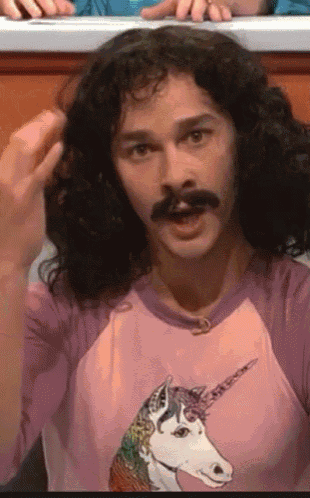

# Блок 3: Computer Vision & GUI — Как заставить веб-камеру узнать вас

Мы научили наш *DataPulse* работать с таблицами (Блок 1) и читать тексты (Блок 2). Но что, если в вашем проекте нужно анализировать изображения? Например, вы делаете сервис **RealtyScope** и хотите по фото квартиры определять: это "бабушкин ремонт" с коврами на стенах или современный лофт? 

Или, как мы сделаем в конце этой лекции, вы хотите написать десктопное приложение для деканата, которое по веб-камере узнает студента и проверяет, сдал ли он домашку.

Добро пожаловать в Компьютерное Зрение (Computer Vision, CV). Раздел машинного обучения, где данные весят гигабайты, а видеокарты плачут горючими слезами.



**Что это такое, если по-простому?**
Это область искусственного интеллекта, которая учит компьютеры "видеть" и "понимать" изображения и видео так, как это делаем мы, люди. Ну, или хотя бы стремится к этому. То есть, не просто хранить картинку как набор пикселей, а *извлекать из нее смысл*.

**Где это уже вокруг нас? Да повсюду!**

*   🚗 **Автопилоты в машинах** (Tesla, Waymo): Машины видят дорогу, знаки, другие машины, пешеходов. Это всё CV!
    

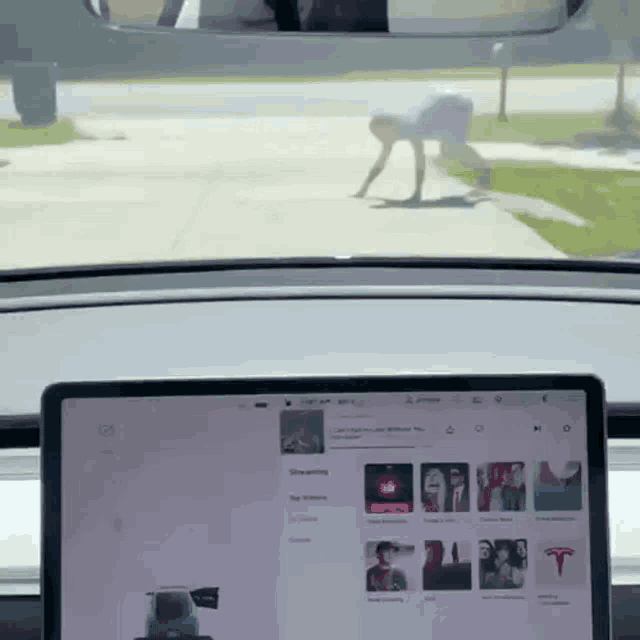

*   📸 **Фильтры в Instagram, Snapchat, TikTok**: Маски, которые идеально ложатся на ваше лицо, эффекты дополненной реальности. Да-да, сначала CV находит ваше лицо, его части (глаза, нос, рот), а потом уже накладывает красоту.
*   🩺 **Медицинская диагностика**: Анализ рентгеновских снимков, МРТ, КТ для поиска опухолей или других патологий. Иногда CV справляется даже лучше человека!
*   🖼️ **Поиск по фото в Google Photos или Яндекс.Картинках**: Вы загружаете фото котика, а поисковик находит похожих котиков. Или вы ищете "закат над морем", и он показывает вам именно такие пейзажи.
*   🔒 **Системы безопасности**: Распознавание лиц для доступа в помещения, отслеживание объектов на камерах видеонаблюдения.
*   🤖 **Робототехника**: Роботы-пылесосы ориентируются в квартире, промышленные роботы берут нужные детали.
*   ... и еще куча всего, от сельского хозяйства (анализ состояния посевов) до спорта (анализ тактики игроков).

**Наш план на сегодня:**
Мы с вами не будем строить Теслу, но попробуем разобраться в основах и сделать свой небольшой, но крутой проект: **систему распознавания лиц в реальном времени!**
То есть, мы научим компьютер:
1.  Находить лица на видео.
2.  "Запоминать" лица (на примере нескольких добровольцев).
3.  И потом узнавать их и подписывать имена прямо на видеопотоке с веб-камеры.

Спойлер: будет немного кода, немного теории, и, надеюсь, много фана! Погнали!

---
## 3.1. Зрение терминатора: Почему картинки — это больно?

Люди смотрят на фотографию кота и видят пушистое создание. Компьютер смотрит на фотографию кота и видит гигантскую таблицу чисел.



Любая цветная картинка в памяти компьютера — это **3D-Тензор** (трехмерная матрица). У нее есть три измерения:
1. **Высота (Height)** — количество пикселей по вертикали.
2. **Ширина (Width)** — количество пикселей по горизонтали.
3. **Каналы (Channels)** — цветовые слои. В формате RGB их три: Красный (Red), Зеленый (Green) и Синий (Blue).

Каждый пиксель в канале — это просто число от $0$ (черный) до $255$ (максимально яркий цвет). 
Давайте докажем это с помощью главной библиотеки для работы со зрением — **OpenCV**.

In [39]:
# Если не установлено: pip install opencv-python numpy
import cv2
import numpy as np

# Скачаем/загрузим какую-нибудь картинку (предположим, у вас в папке есть photo.jpg)
# Для этого примера я создам "синтетическую" картинку (просто матрицу) прямо в коде, 
# чтобы вы могли запустить эту ячейку без реального файла.

# Создаем черный квадрат 100x100 пикселей, 3 канала (цветной). Тип данных: целые числа 8 бит (от 0 до 255)
dummy_image = np.zeros((100, 100, 3), dtype=np.uint8)

# Закрасим верхнюю половину красным
# ВАЖНАЯ БОЛЬ №1: OpenCV читает цвета не в RGB (Red-Green-Blue), а в BGR (Blue-Green-Red)!
# Это исторический костыль из 90-х, когда разработчики камер договорились о таком стандарте.
# Значит, Красный цвет — это [0, 0, 255] (Синий=0, Зеленый=0, Красный=255)
dummy_image[0:50, :, :] = [0, 0, 255] 

print(f"Тип объекта картинки: {type(dummy_image)}")
print(f"Размерность (Shape): {dummy_image.shape} -> (Высота, Ширина, Каналы)")

# Посмотрим на конкретный пиксель (например, x=10, y=10)
pixel_color = dummy_image[10, 10]
print(f"Цвет пикселя (10, 10) в формате BGR: {pixel_color}")

Тип объекта картинки: <class 'numpy.ndarray'>
Размерность (Shape): (100, 100, 3) -> (Высота, Ширина, Каналы)
Цвет пикселя (10, 10) в формате BGR: [  0   0 255]


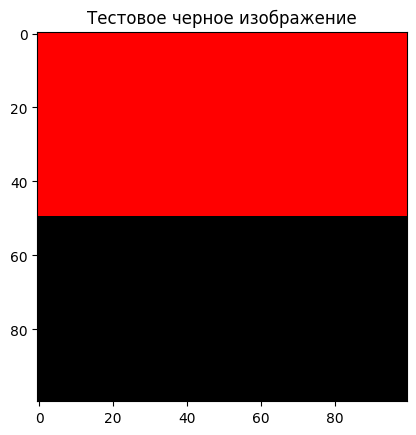

In [45]:
import matplotlib.pyplot as plt # Для отображения картинок прямо в Jupyter Notebook
plt.imshow(cv2.cvtColor(dummy_image, cv2.COLOR_BGR2RGB)) # OpenCV читает в BGR, matplotlib ждет RGB
plt.title("Тестовое черное изображение")
plt.show()

**Для компьютера изображение – это просто... матрица чисел!**

*   **Пиксели**: Каждое изображение состоит из ма-а-аленьких точек, называемых пикселями. Каждый пиксель имеет свой цвет.
*   **Разрешение**: Это количество пикселей по ширине и высоте (например, 1920x1080). Чем больше пикселей, тем детальнее картинка.
*   **Цветовые пространства**:
    *   **Grayscale (Оттенки серого)**: Самый простой вариант. Каждый пиксель – это одно число, обычно от 0 (черный) до 255 (белый).
        *   *Представьте себе старую черно-белую фотографию.*
    *   **RGB (Red, Green, Blue)**: Самое популярное для цветных изображений. Каждый пиксель описывается *тремя* числами – интенсивностью красного, зеленого и синего каналов. Каждое из этих чисел тоже обычно от 0 до 255.
        *   *Смешивая эти три основных цвета в разных пропорциях, мы получаем все остальные цвета радуги.*
    *   **BGR**: То же самое, что RGB, но порядок каналов другой: Blue, Green, Red. **Важно:** OpenCV по умолчанию использует именно BGR! Если вы будете показывать картинку в другой библиотеке (например, Matplotlib), которая ожидает RGB, цвета будут искажены, если не сделать конвертацию.
    *   Есть и другие цветовые пространства (HSV, HSL, LAB), но RGB/BGR и Grayscale – наши основные на сегодня.

**Давайте посмотрим на это в коде!**

In [ ]:
# Загрузим какую-нибудь картинку
# Убедитесь, что 'test_image.jpg' (или ваше имя файла) лежит в той же папке, что и ноутбук,
# или укажите полный путь к файлу.
# Я буду использовать встроенную картинку из face_recognition для примера, чтобы код был самодостаточным.

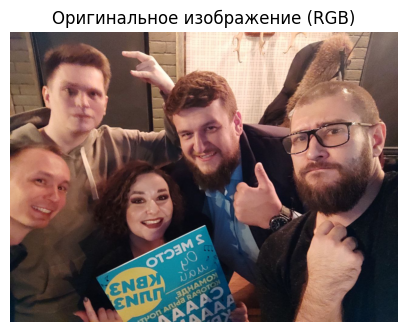

Тип данных изображения: uint8
Форма (размеры) изображения: (958, 1280, 3)


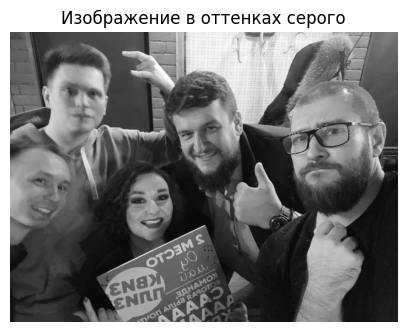

Тип данных grayscale изображения: uint8
Форма (размеры) grayscale изображения: (958, 1280)


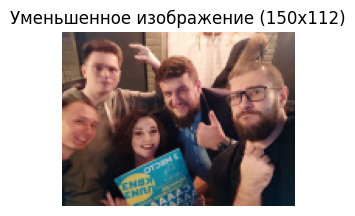

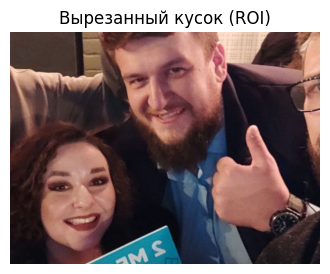

In [46]:
# Укажите путь к вашему изображению
# Предполагается, что Jupyter Notebook запущен из такой директории,
# что этот относительный путь корректен.
# Если нет, используйте абсолютный путь.
your_image_path = "data/1.jpg" # ВАШ ПУТЬ К ФАЙЛУ

try:
    # Загружаем ваше изображение с помощью OpenCV
    # cv2.imread() загружает в BGR формате
    img_bgr = cv2.imread(your_image_path)

    if img_bgr is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение по пути: {your_image_path}. Проверьте путь.")

    # Для единообразия с предыдущими примерами и для matplotlib, получим RGB версию
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Покажем ее с помощью Matplotlib
    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.title("Оригинальное изображение (RGB)")
    plt.axis('off')
    plt.show()

    print(f"Тип данных изображения: {img_rgb.dtype}")
    print(f"Форма (размеры) изображения: {img_rgb.shape}")

except FileNotFoundError as e:
    print(e)
    # Создадим фейковое изображение, чтобы код ниже не падал, если ваше не загрузится
    img_rgb = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8)
    print("Создано случайное изображение для продолжения демонстрации.")
    plt.imshow(img_rgb)
    plt.title("Случайное изображение (RGB) - ОШИБКА ЗАГРУЗКИ ВАШЕГО ФАЙЛА")
    plt.show()
    # И создадим img_bgr на всякий случай, если он понадобится дальше по коду в этой ячейке
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)


# Конвертируем в оттенки серого
# Для конвертации из RGB в Gray используем cv2.cvtColor
# Если исходник был BGR, то cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) # или cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(img_gray, cmap='gray')
plt.title("Изображение в оттенках серого")
plt.axis('off')
plt.show()

print(f"Тип данных grayscale изображения: {img_gray.dtype}")
print(f"Форма (размеры) grayscale изображения: {img_gray.shape}")

# Простые манипуляции
# Ресайз (изменение размера)
if img_rgb is not None and img_rgb.size > 0 : # Проверка, что изображение загружено
    new_width = 150
    ratio = new_width / img_rgb.shape[1]
    new_height = int(img_rgb.shape[0] * ratio)
    resized_img_rgb = cv2.resize(img_rgb, (new_width, new_height), interpolation=cv2.INTER_AREA)

    plt.figure(figsize=(3,3))
    plt.imshow(resized_img_rgb)
    plt.title(f"Уменьшенное изображение ({new_width}x{new_height})")
    plt.axis('off')
    plt.show()

    # Обрезка (Region of Interest - ROI)
    h, w, _ = img_rgb.shape
    roi_rgb = img_rgb[h//4 : 3*h//4, w//4 : 3*w//4]

    plt.figure(figsize=(4,4))
    plt.imshow(roi_rgb)
    plt.title("Вырезанный кусок (ROI)")
    plt.axis('off')
    plt.show()
else:
    print("Пропускаем ресайз и ROI, так как исходное изображение не было загружено.")


### Почему нельзя использовать обычную нейросеть (MLP)?

В Блоке 1 мы написали сеть `nn.Linear`. Почему нельзя засунуть картинку туда?
Возьмем обычное фото с iPhone: разрешение примерно $4000 \times 3000$ пикселей.
$4000 \times 3000 \times 3 \text{ (канала)} = 36,000,000$ входов. 

Если мы создадим всего один скрытый слой на 1000 нейронов, количество весов (связей) между входом и первым слоем будет:
$36,000,000 \times 1000 = 36 \text{ МИЛЛИАРДОВ}$ весов. 

Только для хранения этих весов в оперативной памяти вам понадобится около **144 Гигабайт VRAM**. Для одного слоя! А сеть просто запомнит ваши данные и выдаст 100% переобучение.

### Спасение: Сверточные нейросети (CNN)



В 1989 году Ян Лекун придумал **Свертки (Convolutions)**. Идея гениальна в своей простоте. 
Мы не смотрим на всю картинку целиком. Мы берем маленький квадратик (например, $3 \times 3$ пикселя), который называется **Фильтр (Kernel)**. 
Мы "скользим" этим фильтром по всей картинке слева направо, сверху вниз, как фонариком в темной комнате. 

Фильтр выполняет простейшее математическое умножение пикселей и ищет конкретный паттерн:
* Фильтры первых слоев ищут базовые вещи: вертикальные линии, горизонтальные линии, градиенты цвета.
* Фильтры средних слоев комбинируют линии и ищут: круги, углы, текстуры (например, "шерсть" или "кирпич").
* Фильтры последних слоев ищут: "глаз", "колесо", "нос".

Главная магия: фильтр $3 \times 3$ весит всего 9 параметров! Независимо от того, картинка у вас $100 \times 100$ или $4000 \times 3000$, фильтр один и тот же. Это сократило количество параметров в миллиарды раз и сделало Computer Vision возможным на обычных ПК.

---
## 3.2. Распознавание лиц: От пикселей к векторам (Демо)

Обучать свою CNN для детекции лиц — это отличная тема для курсовой. Но для нашего проекта нам нужен готовый, надежный инструмент.

Многие путают две задачи:
1. **Детекция лица (Face Detection):** Найти квадратик на фото, где находится лицо. Сказать: "Здесь есть человек".
2. **Распознавание лица (Face Recognition):** Сказать: "Это лицо принадлежит Ивану Иванову".

Раньше детекцию делали каскадами Хаара (Haar Cascades) — они быстро работали, но если человек поворачивал голову в профиль, алгоритм слепнул. Сейчас всё делают нейросети.

Мы будем использовать потрясающую высокоуровневую библиотеку `face_recognition`. Под капотом она использует суровую библиотеку `dlib` (написанную на C++) и предобученную нейросеть (ResNet), которая сжимает лицо человека в вектор из 128 чисел (**Face Embedding**).

Как это работает? 
Точно так же, как мы делали со словами в NLP! Модель училась так: ей давали 2 фото одного человека и 1 фото другого. Сеть штрафовали (Loss), если расстояние между векторами одного человека было большим, и поощряли, если оно было маленьким. 
В итоге получилось пространство на 128 измерений, где "мое лицо в очках" и "мое лицо с бородой" находятся математически рядом, а "лицо Бреда Питта" — очень далеко.

## Первый шаг к интеллекту: Обнаружение лиц (Face Detection) 🧐

Мы научились загружать картинки и даже немного их "щупать" (смотреть размеры, цвета). Теперь давайте научим компьютер находить на этих картинках что-то осмысленное, а именно – **лица**!

**Что такое Face Detection?**
Это задача, где цель – найти и выделить на изображении или видеокадре области, содержащие человеческие лица. Обычно результатом является набор прямоугольников (bounding boxes), которые очерчивают каждое найденное лицо.

**Важно:** Обнаружение лиц (Face Detection) – это *не то же самое*, что Распознавание лиц (Face Recognition)!
*   **Detection**: "Ага, вот тут есть лицо!"
*   **Recognition**: "Ага, это лицо Васи Пупкина!"
До распознавания мы еще дойдем, а пока сосредоточимся на поиске.

**Как это работает? Краткий обзор подходов:**

1.  **Классика жанра: Каскады Хаара (Viola-Jones Algorithm)**
    *   Это один из первых реально работающих и быстрых методов, предложенный еще в 2001 году. До сих пор популярен для задач, где нужна скорость.
    *   **Идея на пальцах:**
        1.  Используются простые черно-белые шаблончики – **признаки Хаара**. Представьте себе маленькие прямоугольные области: одна светлая, другая темная. Если наложить такой шаблон на область бровей (темные брови, светлый лоб), получится большое значение. Если на щеку (примерно однотонная) – маленькое.
        2.  Таких признаков очень много, разных форм и размеров.
        3.  С помощью алгоритма **AdaBoost** выбираются самые "полезные" признаки и объединяются в "каскад" классификаторов.
        4.  Изображение сканируется окном разного размера. На каждом шаге окно "прогоняется" через каскад. Если все уровни каскада говорят "да, похоже на лицо", то область помечается как лицо. Если хоть один говорит "нет" – идем дальше, это экономит время.
    *   **Плюсы:** Быстро, есть готовые обученные модели в OpenCV.
    *   **Минусы:** Не очень хорошо работает с лицами в профиль, при сильном наклоне, плохом освещении, частичных перекрытиях. Чувствителен к ложным срабатываниям.

    *(Можно показать картинку-пример признаков Хаара)*

2.  **Более продвинутый вариант: HOG + SVM (Histogram of Oriented Gradients + Support Vector Machine)**
    *   **HOG**: Этот метод описывает объект (в нашем случае лицо) через распределение направлений градиентов (насколько резко меняется яркость и куда). Грубо говоря, он смотрит на контуры и формы.
    *   **SVM**: Затем эти "дескрипторы" HOG подаются на вход простому, но эффективному классификатору – машине опорных векторов (SVM), который решает, лицо это или нет.
    *   **Плюсы:** Точнее, чем каскады Хаара, лучше справляется с вариациями освещения. Используется по умолчанию в библиотеке `dlib` (и, соответственно, в `face_recognition` для детекции, если не указан CNN).
    *   **Минусы:** Медленнее, чем каскады Хаара.

3.  **Тяжелая артиллерия: CNN-based детекторы (Convolutional Neural Networks)**
    *   Современные детекторы лиц (например, MTCNN, SSD, YOLO-face) основаны на сверточных нейронных сетях.
    *   **Плюсы:** Самая высокая точность, отлично работают с трудными случаями (разные ракурсы, освещение, перекрытия).
    *   **Минусы:** Требуют значительно больше вычислительных ресурсов (особенно GPU для реального времени), медленнее на CPU по сравнению с классическими методами. `face_recognition` позволяет использовать CNN-модель для детекции.

**Давайте попробуем на практике!**
Сначала используем каскад Хаара из OpenCV, а потом посмотрим на детектор из `face_recognition`.

In [49]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 1.2 MB/s eta 0:00:0000:0100:03
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 406.5 kB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dlib: filename=dlib-20.0.1-cp312-cp312-linux_x86_64.whl size=4160920 sha256=db9281fcb6766c282bc4ab234462f5c753a6884aafa0549e9c9ee4b8ecd3cebb
  Stored in directory: /home/daniel/.cache/pip/wheels/0d/a3/e4/89c1a393cbb86433554f89465e1f2b4c647bca9f256b454b62
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566241 sha256=b41f1cdc13257093b9194de47e9c27a7a478b3912afe73f2728fb98e2c9752f4
  Stored in directory: /home/daniel/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2

Каскад Хаара успешно загружен из: /home/daniel/misis/venv/lib/python3.12/site-packages/cv2/data/haarcascade_frontalface_default.xml
Найдено лиц (Хаар) на 'd.jpg': 11


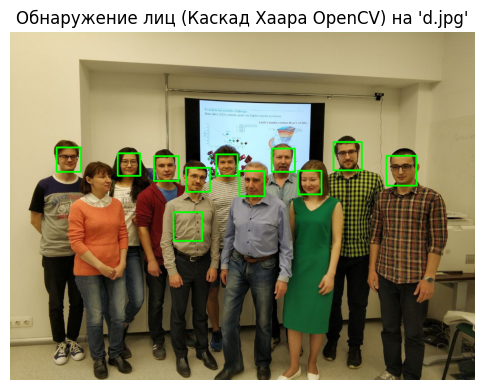

Найдено лиц (face_recognition HOG) на 'multi-face image': 10


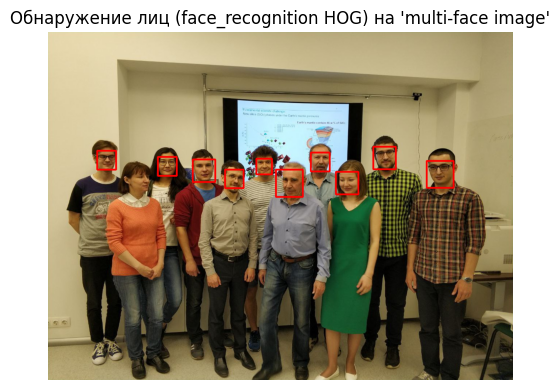

In [56]:
import face_recognition
# Укажите путь к вашему основному изображению
your_image_path_d = "data/2.jpg" # ВАШ ПУТЬ К ФАЙЛУ d.jpg

# (Опционально) Укажите путь к изображению с несколькими лицами, если есть
# Если нет, оставим пустым или None, и будем использовать ваше одиночное фото
your_multi_face_image_path = "data/2.jpg" # или "путь/к/вашему/фото_с_несколькими_лицами.jpg"

try:
    # Загружаем ваше изображение (d.jpg)
    img_bgr_d = cv2.imread(your_image_path_d)
    if img_bgr_d is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение: {your_image_path_d}")
    img_rgb_d = cv2.cvtColor(img_bgr_d, cv2.COLOR_BGR2RGB)
    img_gray_d = cv2.cvtColor(img_bgr_d, cv2.COLOR_BGR2GRAY) # Для каскада Хаара

except FileNotFoundError as e:
    print(e)
    # Заглушка, если не удалось загрузить
    img_rgb_d = np.random.randint(0, 256, (400, 300, 3), dtype=np.uint8)
    img_gray_d = cv2.cvtColor(img_rgb_d, cv2.COLOR_RGB2GRAY)
    print("Создано случайное изображение (d.jpg) для продолжения демонстрации.")


# --- Обнаружение лиц с помощью Каскада Хаара (OpenCV) ---
haar_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
import os
if not os.path.exists(haar_cascade_path):
    print(f"Ошибка: Не найден файл каскада Хаара по пути: {haar_cascade_path}")
    haar_cascade_path = None # Чтобы код ниже не падал, а выводил сообщение

if haar_cascade_path:
    face_cascade = cv2.CascadeClassifier(haar_cascade_path)
    if face_cascade.empty():
        print("Ошибка: Не удалось загрузить каскад Хаара. Проверьте путь.")
    else:
        print(f"Каскад Хаара успешно загружен из: {haar_cascade_path}")
        faces_haar = face_cascade.detectMultiScale(img_gray_d, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        print(f"Найдено лиц (Хаар) на 'd.jpg': {len(faces_haar)}")

        img_with_rects_haar = img_rgb_d.copy()
        for (x, y, w, h) in faces_haar:
            cv2.rectangle(img_with_rects_haar, (x, y), (x+w, y+h), (0, 255, 0), 3)

        plt.figure(figsize=(6,6))
        plt.imshow(img_with_rects_haar)
        plt.title("Обнаружение лиц (Каскад Хаара OpenCV) на 'd.jpg'")
        plt.axis('off')
        plt.show()
else:
    print("Пропускаем детекцию Хаара, так как каскад не найден.")


# --- Обнаружение лиц с помощью face_recognition (HOG по умолчанию) ---
# Загружаем изображение для face_recognition (оно должно быть RGB)
# Будем использовать img_rgb_d (ваше фото d.jpg)
# Если у вас есть отдельное фото с несколькими лицами, загрузим его:
if your_multi_face_image_path:
    try:
        img_multi_bgr = cv2.imread(your_multi_face_image_path)
        if img_multi_bgr is None: raise FileNotFoundError
        img_multi_rgb_fr = cv2.cvtColor(img_multi_bgr, cv2.COLOR_BGR2RGB)
        image_for_fr_detection = img_multi_rgb_fr
        fr_title_suffix = "на 'multi-face image'"
    except FileNotFoundError:
        print(f"Файл '{your_multi_face_image_path}' не найден, используем 'd.jpg' для face_recognition.")
        image_for_fr_detection = img_rgb_d
        fr_title_suffix = "на 'd.jpg'"
else:
    image_for_fr_detection = img_rgb_d
    fr_title_suffix = "на 'd.jpg'"


if image_for_fr_detection.size > 0: # Проверка, что изображение загружено
    face_locations_hog = face_recognition.face_locations(image_for_fr_detection, model="hog")
    print(f"Найдено лиц (face_recognition HOG) {fr_title_suffix}: {len(face_locations_hog)}")

    img_with_rects_fr_hog = image_for_fr_detection.copy()
    for (top, right, bottom, left) in face_locations_hog:
        cv2.rectangle(img_with_rects_fr_hog, (left, top), (right, bottom), (255, 0, 0), 3)

    plt.figure(figsize=(6,6))
    plt.imshow(img_with_rects_fr_hog)
    plt.title(f"Обнаружение лиц (face_recognition HOG) {fr_title_suffix}")
    plt.axis('off')
    plt.show()
else:
    print("Пропускаем детекцию face_recognition, так как изображение не загружено.")



Запускаем CNN детектор лиц ...
Найдено лиц (face_recognition CNN) на 'multi-face image': 11


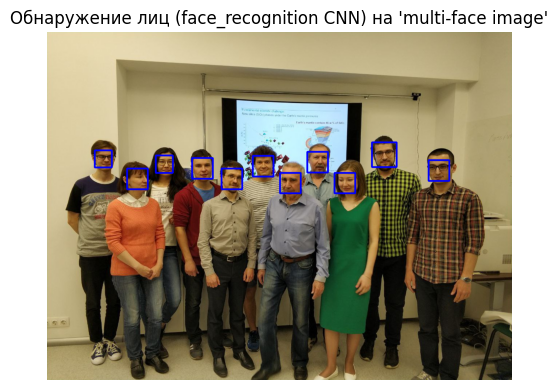

In [57]:
print("\nЗапускаем CNN детектор лиц ...")
if image_for_fr_detection.size > 0:
    face_locations_cnn = face_recognition.face_locations(image_for_fr_detection, model="cnn")
    print(f"Найдено лиц (face_recognition CNN) {fr_title_suffix}: {len(face_locations_cnn)}")

    img_with_rects_fr_cnn = image_for_fr_detection.copy()
    for (top, right, bottom, left) in face_locations_cnn:
        cv2.rectangle(img_with_rects_fr_cnn, (left, top), (right, bottom), (0, 0, 255), 3)

    plt.figure(figsize=(6,6))
    plt.imshow(img_with_rects_fr_cnn)
    plt.title(f"Обнаружение лиц (face_recognition CNN) {fr_title_suffix}")
    plt.axis('off')
    plt.show()
else:
    print("Пропускаем CNN детекцию, изображение не загружено.")

In [58]:
# Для работы этого кода потребуются библиотеки: 
# pip install dlib face_recognition opencv-python
# ВНИМАНИЕ: Установка dlib на Windows может потребовать установленных C++ Build Tools!

import face_recognition
import numpy as np
import cv2

print("Запускаем систему идентификации Скайнет... 👁️")

# В реальном приложении мы бы загружали фото с диска:
# image_ivan = face_recognition.load_image_file("ivan_passport.jpg")

# Но для демонстрации работы алгоритма мы сгенерируем фиктивные "эмбеддинги"
# Представьте, что это результат работы нейросети, которая уже посмотрела на фото:
# Вектор длиной 128 чисел (отрицательные и положительные float)
ivan_face_encoding = np.random.randn(128) * 0.1 
petr_face_encoding = np.random.randn(128) * 0.1

# Внезапно веб-камера фиксирует новое лицо! 
# (Допустим, это Иван, но сфотканный в плохом освещении, поэтому вектор чуть-чуть другой)
# Добавляем "шум" к вектору Ивана
unknown_face_encoding = ivan_face_encoding + (np.random.randn(128) * 0.02)

# Как понять, кто перед камерой? 
# Мы должны измерить Евклидово расстояние (расстояние по прямой) 
# между неизвестным вектором и всеми векторами в нашей базе.

# 1. Расстояние до Ивана
distance_to_ivan = np.linalg.norm(ivan_face_encoding - unknown_face_encoding)
# 2. Расстояние до Петра
distance_to_petr = np.linalg.norm(petr_face_encoding - unknown_face_encoding)

print(f"Математическое расстояние до эталона Ивана: {distance_to_ivan:.4f}")
print(f"Математическое расстояние до эталона Петра: {distance_to_petr:.4f}")

# Библиотека face_recognition рекомендует порог 0.6. 
# Если расстояние < 0.6 — это один и тот же человек.
# Если > 0.6 — это разные люди.
TOLERANCE = 0.6

if distance_to_ivan < TOLERANCE:
    print("\n✅ Доступ разрешен: Здравствуйте, Иван!")
elif distance_to_petr < TOLERANCE:
    print("\n✅ Доступ разрешен: Здравствуйте, Петр!")
else:
    print("\n🚨 Доступ запрещен: Неизвестное лицо!")

Запускаем систему идентификации Скайнет... 👁️
Математическое расстояние до эталона Ивана: 0.2268
Математическое расстояние до эталона Петра: 1.6930

✅ Доступ разрешен: Здравствуйте, Иван!


---
## Ищем препода в толпе (Live Coding на реальных фото)

Синтетические массивы `np.random.randn` — это хорошо для понимания математики, но это скучно. Давайте посмотрим, как эта магия работает в реальном мире. 

У нас есть папка `/data/`, в которой лежат три мои фотографии:
* `/data/3.jpg` — Моя одиночная фотография (крупный план, где я красивый и выспавшийся). Это будет наш **Эталон** (Reference).
* `/data/1.jpg` и `/data/2.jpg` — Групповые фотографии, где я стою в толпе других людей.

Наша задача: написать скрипт, который "выучит" мое лицо по фото №3, затем просканирует групповое фото №1, найдет там **все** лица и обведет мое лицо зеленой рамкой, а всех остальных — красной. Почувствуйте себя разработчиком системы наблюдения для спецслужб!

*(Примечание: в Jupyter Notebook мы не используем `cv2.imshow()`, так как он намертво вешает ядро браузера. Мы будем рисовать картинки через `matplotlib`)*

Инициализация протокола Скайнет... 👁️

Сканируем эталонное фото...
✅ Лицо преподавателя успешно переведено в вектор из 128 чисел!

Сканируем групповое фото data/2.jpg...
Найдено лиц в толпе: 5


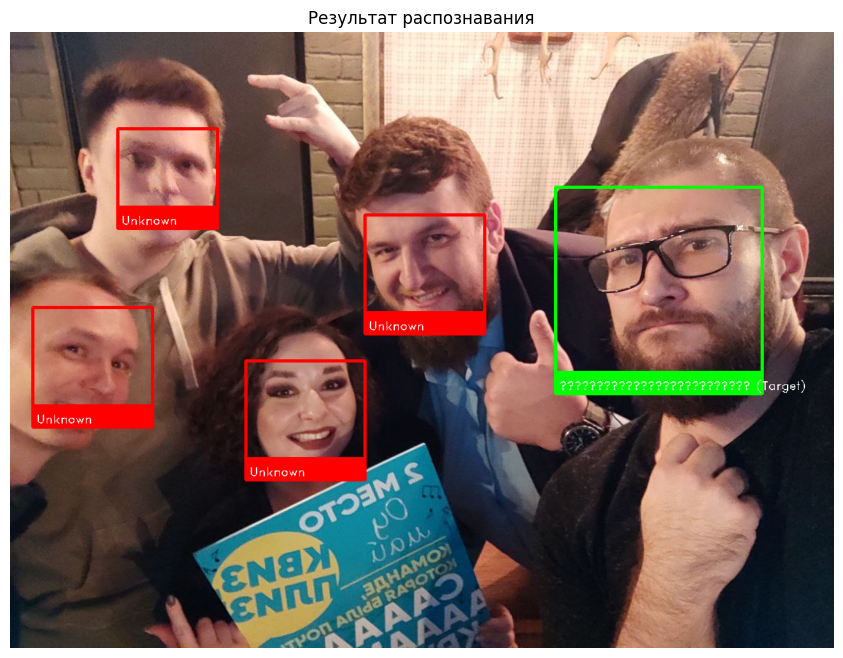

Миссия выполнена. Преподаватель идентифицирован.


In [64]:
# pip install face_recognition opencv-python matplotlib
import face_recognition
import cv2
import matplotlib.pyplot as plt

print("Инициализация протокола Скайнет... 👁️\n")

# --- ШАГ 1: ОБУЧЕНИЕ (Получаем эталон) ---
# Загружаем одиночное фото. 
# Фишка: face_recognition.load_image_file сразу грузит картинку в правильном RGB формате!
try:
    reference_image = face_recognition.load_image_file("data/3.jpg")
except FileNotFoundError:
    print("❌ Файл data/3.jpg не найден. Положите свои фото в нужную папку!")
    # Здесь код упадет, если вы не подготовили данные, но мы идем дальше, предполагая, что они есть.

# Находим векторы (эмбеддинги) всех лиц на фото. Мы знаем, что там только я, берем первое лицо [0]
print("Сканируем эталонное фото...")
reference_encodings = face_recognition.face_encodings(reference_image)

if len(reference_encodings) == 0:
    print("❌ На эталонном фото не найдено ни одного лица! Попробуйте фото посветлее.")
else:
    my_face_encoding = reference_encodings[0]
    print("✅ Лицо преподавателя успешно переведено в вектор из 128 чисел!\n")


# --- ШАГ 2: ПОИСК В ТОЛПЕ ---
print("Сканируем групповое фото data/2.jpg...")
group_image = face_recognition.load_image_file("data/1.jpg")

# Находим КООРДИНАТЫ всех лиц на групповом фото (где рисовать квадратики)
face_locations = face_recognition.face_locations(group_image)
# Находим ЭМБЕДДИНГИ всех найденных лиц
face_encodings = face_recognition.face_encodings(group_image, face_locations)

print(f"Найдено лиц в толпе: {len(face_locations)}")

# --- ШАГ 3: СРАВНЕНИЕ И ОТРИСОВКА ---
# OpenCV работает с картинками, поэтому создаем копию группового фото для рисования рамок
# Конвертируем RGB обратно в BGR, потому что функции рисования OpenCV (cv2.rectangle) ждут BGR. 
# Да, это костыль. Да, к этому придется привыкнуть.
output_image = cv2.cvtColor(group_image, cv2.COLOR_RGB2BGR)

# Проходимся циклом по всем найденным лицам (zip объединяет координаты и векторы в пары)
for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    
    # Сравниваем текущее лицо из толпы с моим эталонным лицом
    # tolerance=0.6 - это жесткость проверки. Чем меньше, тем строже фейсконтроль.
    matches = face_recognition.compare_faces([my_face_encoding], face_encoding, tolerance=0.6)
    
    # matches - это список булевых значений (в нашем случае одно: [True] или [False])
    if True in matches:
        # Это Я! Рисуем ЗЕЛЕНУЮ рамку (BGR: Blue=0, Green=255, Red=0)
        color = (0, 255, 0)
        label = "Преподаватель (Target)"
    else:
        # Это кто-то другой. Рисуем КРАСНУЮ рамку (BGR: Blue=0, Green=0, Red=255)
        color = (0, 0, 255)
        label = "Unknown"
        
    # Рисуем рамку (Bounding Box) вокруг лица
    # thickness=3 - толщина линии
    cv2.rectangle(output_image, (left, top), (right, bottom), color, 3)
    
    # Подписываем текст снизу
    cv2.rectangle(output_image, (left, bottom - 35), (right, bottom), color, cv2.FILLED)
    cv2.putText(output_image, label, (left + 6, bottom - 6), cv2.FONT_HERSHEY_DUPLEX, 0.6, (255, 255, 255), 1)

# --- ШАГ 4: ВЫВОД РЕЗУЛЬТАТА ---
# Снова конвертируем в RGB для красивого вывода в matplotlib
final_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

# Настраиваем размер графика в Jupyter
plt.figure(figsize=(12, 8))
plt.imshow(final_image_rgb)
plt.axis('off') # Убираем уродливые оси координат с пикселями
plt.title("Результат распознавания")
plt.show()

print("Миссия выполнена. Преподаватель идентифицирован.")

### Разбор полетов: Что тут произошло?

1. **`face_locations`**: Сначала алгоритм сканирует фото и ищет паттерны, похожие на "глаза-нос-рот". Он возвращает нам Bounding Boxes (ограничивающие рамки в пикселях: верх, право, низ, лево).
2. **`face_encodings`**: Затем нейросеть берет каждый вырезанный кусочек лица, выравнивает его (чтобы глаза были на одном уровне) и прогоняет через сверточные слои (CNN), получая на выходе 128 чисел.
3. **`compare_faces`**: Под капотом считает евклидово расстояние. Если расстояние между вектором из фото `/data/3.jpg` и вектором из `/data/1.jpg` меньше $0.6$ — алгоритм говорит `True`. Мы нашли совпадение!

**Обратите внимание на боль с цветами:** Библиотека `face_recognition` загрузила фото в формате RGB. Мы нашли лица. Потом нам нужно было нарисовать на фото квадратики. Для этого мы взяли OpenCV (`cv2.rectangle`). Но OpenCV из-за своего исторического легаси требует формат BGR! Поэтому мы прыгали туда-сюда с помощью `cv2.cvtColor`. Запомните этот момент, он сэкономит вам часы дебаггинга, когда у вас "почему-то" лица будут обводиться синим вместо красного.

<div style="background-color: #f8f9fa; border-left: 8px solid #ffc107; padding: 20px; margin-top: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h2 style="color: #ffc107; margin-top: 0; text-shadow: 1px 1px 1px rgba(0,0,0,0.1);">📚 Темы для самостоятельного изучения (Блок 3 - Свертки и Лица)</h2>
    <p style="font-size: 1.1em; color: #333;">Компьютерное зрение может сожрать всю вашу память, если не понимать, как оно работает. Рекомендую изучить:</p>
    <ul style="line-height: 1.8; color: #444;">
        <li>
            <strong><a href="https://poloclub.github.io/cnn-explainer/" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">CNN Explainer</a></strong> 
            — Потрясающая интерактивная визуализация в браузере. Вы своими глазами увидите, как сверточный фильтр (kernel) скользит по картинке и ищет паттерны. Обязательно к просмотру!
        </li>
        <li>
            <strong>Документация face_recognition:</strong> Изучите <a href="https://github.com/ageitgey/face_recognition" target="_blank" style="color: #0056b3; text-decoration: none;">GitHub репозиторий проекта</a>. Там есть примеры использования с разными веб-фреймворками и даже ускорение на GPU с помощью параметра <code>model="cnn"</code>.
        </li>
        <li>
            <strong>Глубокое погружение в OpenCV:</strong> Почитайте, почему OpenCV использует формат BGR вместо RGB, и изучите функции геометрических трансформаций (warp, resize, crop) — они понадобятся вам при подготовке любого кастомного датасета картинок.
        </li>
    </ul>
</div>

---
## 3.3. Камера в вебе: Транслируем зрение терминатора через FastAPI

В предыдущем примере мы красиво отрисовали графики в Jupyter. Но в реальном проекте *DataPulse* у нас нет Jupyter. У нас есть бэкенд на FastAPI, который работает где-то в Docker-контейнере на сервере. 

Как нам передать видео с камеры, распознать лица на лету и показать это пользователю в браузере?

### Иллюзия видео (MJPEG Streaming)


Нужно понимать одну простую вещь: **видео не существует**. Видео — это просто картинки (кадры), которые меняются со скоростью 30 штук в секунду (FPS), обманывая ваш мозг.

Если мы хотим транслировать видео через обычный HTTP-запрос в FastAPI, мы используем технологию **Motion JPEG (MJPEG)**.
Обычно HTTP-запрос работает так: клиент спросил -> сервер ответил -> соединение закрылось. 
Но в FastAPI мы можем вернуть `StreamingResponse`. Это специальный ответ, который говорит браузеру: *"Эй, не закрывай соединение! Я буду бесконечно кидать тебе картинки одну за другой, разделяя их специальным маркером (boundary)"*.

Давайте напишем этот эндпоинт. Этот код вы можете скопировать в свой `api/src/main.py`.

*(Примечание: Запускать этот код внутри Docker сложнее, так как контейнеру нужно дать права на доступ к USB-камере вашего хоста (`--device=/dev/video0`). Пока что мы тестируем это локально.)*

In [68]:
import cv2
import face_recognition
from fastapi import FastAPI
from fastapi.responses import StreamingResponse, HTMLResponse
import uvicorn
import threading

# Создаем приложение
app = FastAPI(title="FaceCheck Streamer")

# --- ВАШ ЭТАЛОН (Загружаем один раз при старте) ---
try:
    reference_image = face_recognition.load_image_file("/data/3.jpg")
    reference_encoding = face_recognition.face_encodings(reference_image)[0]
    print("✅ Эталон загружен. Скайнет готов к трансляции.")
except Exception as e:
    print("⚠️ Ошибка загрузки эталона. Трансляция будет работать, но без распознавания.")
    reference_encoding = None

# --- ФУНКЦИЯ ГЕНЕРАЦИИ КАДРОВ ---
def generate_frames():
    # Подключаемся к веб-камере (0 - дефолтная камера ноутбука)
    camera = cv2.VideoCapture(0)
    
    # Сбрасываем разрешение для скорости (опционально)
    # camera.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    # camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    while True:
        # Читаем кадр с камеры
        success, frame = camera.read()
        if not success:
            break
            
        # Для ускорения процесса мы можем уменьшить кадр перед распознаванием
        # (Лица ищем на маленьком кадре, а рисуем на большом)
        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
        
        # Конвертируем BGR (OpenCV) в RGB (face_recognition)
        rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)
        
        # Ищем лица на уменьшенном кадре
        face_locations = face_recognition.face_locations(rgb_small_frame)
        
        # Если у нас есть эталон, пытаемся узнать лицо
        if reference_encoding is not None and len(face_locations) > 0:
            face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations)
            
            for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
                # Сравниваем
                matches = face_recognition.compare_faces([reference_encoding], face_encoding, tolerance=0.6)
                
                # Масштабируем координаты обратно на оригинальный кадр (мы же уменьшали его в 4 раза)
                top *= 4; right *= 4; bottom *= 4; left *= 4
                
                if True in matches:
                    # Это Я!
                    cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
                    cv2.putText(frame, "ACCESS GRANTED", (left, bottom + 25), cv2.FONT_HERSHEY_DUPLEX, 0.7, (0, 255, 0), 1)
                else:
                    # Незнакомец
                    cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 2)
                    cv2.putText(frame, "UNKNOWN", (left, bottom + 25), cv2.FONT_HERSHEY_DUPLEX, 0.7, (0, 0, 255), 1)

        # Конвертируем готовый кадр с рамками в формат JPEG (в байты)
        ret, buffer = cv2.imencode('.jpg', frame)
        frame_bytes = buffer.tobytes()
        
        # МАГИЯ YIELD: Отдаем байты кадра по стандарту multipart/x-mixed-replace
        # Это формат, который понимают все браузеры для потокового видео
        yield (b'--frame\r\n'
               b'Content-Type: image/jpeg\r\n\r\n' + frame_bytes + b'\r\n')

    # Если цикл прервался (камера отключилась), освобождаем ресурс
    camera.release()

# --- ЭНДПОИНТ ВИДЕОПОТОКА ---
@app.get("/video_feed")
def video_feed():
    # Возвращаем StreamingResponse, передавая ему нашу бесконечную функцию (генератор)
    return StreamingResponse(generate_frames(), media_type="multipart/x-mixed-replace; boundary=frame")

# --- ЭНДПОИНТ ФРОНТЕНДА (Чтобы было где смотреть) ---
@app.get("/")
def index():
    # Просто отдаем кусок HTML, где тег <img> смотрит на наш стриминг-эндпоинт!
    html_content = """
    <html>
        <head>
            <title>DataPulse: FaceCheck Stream</title>
            <style>
                body { background-color: #222; color: white; text-align: center; font-family: sans-serif; }
                img { border: 5px solid #555; border-radius: 10px; margin-top: 20px; max-width: 100%; }
            </style>
        </head>
        <body>
            <h1>Служба безопасности Скайнет</h1>
            <img src="/video_feed" width="800" height="600" />
        </body>
    </html>
    """
    return HTMLResponse(content=html_content)

# В Jupyter Notebook запускать uvicorn нужно аккуратно (он блокирует ячейку).
# Если хотите запустить прямо здесь, раскомментируйте строчки ниже (остановить можно будет прерыванием ядра):
import nest_asyncio
nest_asyncio.apply()
uvicorn.run(app, host="0.0.0.0", port=8000)

⚠️ Ошибка загрузки эталона. Трансляция будет работать, но без распознавания.


RuntimeError: asyncio.run() cannot be called from a running event loop

---
### ⚠️ Внимание: Краш-тест Jupyter Notebook

Если вы попытаетесь запустить этот код прямо здесь, в ячейке Jupyter, с помощью команды `uvicorn.run(app)`, вы с вероятностью 99% получите красную простыню текста:
`RuntimeError: asyncio.run() cannot be called from a running event loop`

**Почему это происходит?**
Jupyter Notebook сам по себе работает внутри асинхронного цикла событий (Event Loop), чтобы интерфейс не зависал, пока выполняется ваш код. Сервер `Uvicorn` пытается запустить свой собственный цикл поверх существующего. Python бьет по рукам и говорит: "Два цикла в одном потоке запускать нельзя!".

**Главное правило Data Science:**
Jupyter Notebook нужен для исследования данных (EDA), рисования графиков и тестов ML-моделей. **Jupyter не предназначен для запуска веб-серверов и продакшена.**

Чтобы всё заработало правильно, код нашего сервера должен лежать в обычном `.py` файле. Давайте воспользуемся магической командой Jupyter `%%writefile`, чтобы сохранить код из ячейки прямо на жесткий диск.

In [70]:
%%writefile face_streamer.py
import cv2
import face_recognition
from fastapi import FastAPI
from fastapi.responses import StreamingResponse, HTMLResponse

# Создаем приложение
app = FastAPI(title="FaceCheck Streamer")

# --- ВАШ ЭТАЛОН (Загружаем один раз при старте) ---
try:
    reference_image = face_recognition.load_image_file("data/3.jpg") # Укажите правильный путь!
    reference_encoding = face_recognition.face_encodings(reference_image)[0]
    print("✅ Эталон загружен. Скайнет готов к трансляции.")
except Exception as e:
    print("⚠️ Ошибка загрузки эталона. Трансляция будет работать, но без распознавания.")
    reference_encoding = None

def generate_frames():
    camera = cv2.VideoCapture(0)
    
    while True:
        success, frame = camera.read()
        if not success:
            break
            
        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
        rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)
        face_locations = face_recognition.face_locations(rgb_small_frame)
        
        if reference_encoding is not None and len(face_locations) > 0:
            face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations)
            
            for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
                matches = face_recognition.compare_faces([reference_encoding], face_encoding, tolerance=0.6)
                top *= 4; right *= 4; bottom *= 4; left *= 4
                
                if True in matches:
                    cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
                    cv2.putText(frame, "ACCESS GRANTED", (left, bottom + 25), cv2.FONT_HERSHEY_DUPLEX, 0.7, (0, 255, 0), 1)
                else:
                    cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 2)
                    cv2.putText(frame, "UNKNOWN", (left, bottom + 25), cv2.FONT_HERSHEY_DUPLEX, 0.7, (0, 0, 255), 1)

        ret, buffer = cv2.imencode('.jpg', frame)
        frame_bytes = buffer.tobytes()
        
        yield (b'--frame\r\n'
               b'Content-Type: image/jpeg\r\n\r\n' + frame_bytes + b'\r\n')

    camera.release()

@app.get("/video_feed")
def video_feed():
    return StreamingResponse(generate_frames(), media_type="multipart/x-mixed-replace; boundary=frame")

@app.get("/")
def index():
    html_content = """
    <html>
        <head>
            <title>DataPulse: FaceCheck Stream</title>
            <style>
                body { background-color: #222; color: white; text-align: center; font-family: sans-serif; }
                img { border: 5px solid #555; border-radius: 10px; margin-top: 20px; max-width: 100%; }
            </style>
        </head>
        <body>
            <h1>Служба безопасности Скайнет</h1>
            <img src="/video_feed" width="800" height="600" />
        </body>
    </html>
    """
    return HTMLResponse(content=html_content)

Overwriting face_streamer.py


### 🚀 Как запустить сервер?

Ячейка выше только что создала файл `face_streamer.py` в той же папке, где лежит эта тетрадка. 

Чтобы запустить веб-камеру и сервер:
1. Откройте **Терминал** (в Linux, Mac или терминал внутри PyCharm/VSCode).
2. Перейдите в папку с файлом.
3. Выполните команду:
   `uvicorn face_streamer:app --reload`
4. Откройте браузер и перейдите по адресу: **http://localhost:8000**

Улыбнитесь, вас снимает скрытая камера! 📸

---
### 🚨 Разбор ошибки: "can't open camera by index"

Если при запуске сервера вы увидели в терминале страшную ошибку:
`OpenCV(4.13.0) ... VIDEOIO(V4L2:/dev/video0): can't open camera by index`

Поздравляю! Вы только что столкнулись с суровой реальностью взаимодействия софта и "железа". 
Ваш код `cv2.VideoCapture(0)` попытался достучаться до устройства `/dev/video0` (дефолтная веб-камера), но операционная система захлопнула дверь перед его носом. 

**Почему это происходит (Чек-лист отладки):**

1. **Вы запускаете это в WSL2 (Windows Subsystem for Linux)?**
   * *Проблема:* WSL — это виртуальная машина. По умолчанию Windows не прокидывает USB-устройства (веб-камеру) внутрь Linux. OpenCV внутри WSL физически не видит вашу камеру.
   * *Решение:* Запускать скрипт стримера в "родном" Windows Python, либо настраивать проброс USB через `usbipd-win` (это больно, не рекомендую для новичков).
2. **Вы запускаете это в Docker?**
   * *Проблема:* Контейнеры изолированы от железа хоста.
   * *Решение:* Нужно запускать контейнер с флагом `--device=/dev/video0:/dev/video0`.
3. **Камера уже занята?**
   * Если у вас открыт Zoom, Discord, Telegram-звонок или даже другая ячейка Jupyter, которая уже захватила камеру, вторая программа получит отказ. Камера — это монопольный ресурс.
4. **Паранойя операционной системы (Mac/Windows):**
   * В Windows 11 и macOS есть настройки приватности. Проверьте, разрешен ли вашему терминалу (или IDE) доступ к камере в системных настройках.

### 🩹 Как сделать код отказоустойчивым?

В нашем сервисе `face_streamer.py` цикл `while True:` просто прервется (`break`), если камера не откроется. В браузере вы увидите разорванную картинку.

В реальном продакшене (даже в MVP) мы должны обрабатывать такие вещи изящно. Давайте добавим "заглушку": если камеры нет, мы будем транслировать статичную картинку с текстом ошибки, чтобы пользователь понимал, что сервер жив, просто ослеп.

### Как это работает: Объяснение магии

Это один из самых элегантных архитектурных паттернов для интеграции Computer Vision в веб.

1. **Генератор `yield`**: Обратите внимание на функцию `generate_frames()`. Мы не используем `return`. Мы используем `yield`. Это превращает функцию в генератор. Она не отдает весь результат сразу, она "выплевывает" кадры по одному, приостанавливаясь до следующего запроса.
2. **multipart/x-mixed-replace**: Это древний, но невероятно надежный HTTP-стандарт. Он позволяет серверу сказать браузеру: "Я буду присылать тебе части ответа, и каждая новая часть должна **заменять** предыдущую".
3. **Тег `<img>`**: Нам не нужен сложный плеер (как для YouTube) или WebSocket. Самый обычный HTML-тег `<img>` умеет нативно читать поток MJPEG. Он просто непрерывно перерисовывает картинку, создавая видео!

**Минусы такого подхода:**
Вам нужно понимать, что каждая открытая вкладка в браузере будет запускать свой инстанс камеры (или пытаться прочитать с нее). MJPEG очень "прожорлив" к сети (ведь мы шлем несжатые JPEG кадры, а не сжатый кодек вроде H.264). Но для внутренних MVP (Minimum Viable Product) и систем контроля (вроде нашего FaceCheck для лекций) — это идеальное и быстрое решение.

---
##  Упаковка в Docker: Инкапсуляция Скайнета

Мы подошли к финалу. В вашем проекте *DataPulse* все сервисы должны работать в Docker. Наш сервис распознавания лиц — не исключение. 

Однако работа с видеокамерой из-под Docker (особенно на Windows/WSL2) — это классический пример "инженерного ада". Давайте разберемся, как упаковать наше приложение и как прокинуть в него "глаза".

### Шаг 1: Пишем Dockerfile

Нам нужен образ, в котором уже установлены тяжелые библиотеки: `dlib`, `opencv` и `face_recognition`. 
*Внимание: Сборка dlib из исходников внутри Docker может занять 10-15 минут, так как это суровый C++ код.*

In [ ]:
# %%writefile Dockerfile
# Используем официальный образ Python
FROM python:3.11-slim

# Устанавливаем системные зависимости для OpenCV и dlib
RUN apt-get update && apt-get install -y \
    build-essential \
    cmake \
    libopenblas-dev \
    libx11-dev \
    libgtk-3-dev \
    libboost-python-dev \
    libboost-thread-dev \
    python3-dev \
    libgl1-mesa-glx \
    libglib2.0-0 \
    && rm -rf /var/lib/apt/lists/*

# Создаем рабочую директорию
WORKDIR /app

# Копируем зависимости
COPY requirements.txt .
# Устанавливаем библиотеки
RUN pip install --no-cache-dir -r requirements.txt

# Копируем код и данные (фото эталона)
COPY face_streamer.py .
COPY data/ /data/

# Открываем порт для FastAPI
EXPOSE 8000

# Запускаем сервер
CMD ["uvicorn", "face_streamer:app", "--host", "0.0.0.0", "--port", "8000"]

### Шаг 2: Настраиваем docker-compose.yml

Чтобы не вводить длинные команды в терминале, мы опишем запуск в `docker-compose`. Обратите внимание на секцию `devices`.

```yaml
# %%writefile docker-compose.yml
version: '3.8'

services:
  face-check:
    build: .
    ports:
      - "8000:8000"
    devices:
      - "/dev/video0:/dev/video0" # Проброс камеры внутрь контейнера
    volumes:
      - ./data:/data # Чтобы можно было менять фото эталона без пересборки
    restart: always

---
### 🛠️ Спец-операция: Проброс камеры в WSL2

Если вы просто напишете `docker-compose up`, вы получите ту же ошибку: `can't open camera`. Почему? Потому что ядро WSL2 — это виртуальная машина, и она не знает, что у вашего ноутбука есть USB-камера.

**Инструкция для тех, кто на WSL2 (Windows):**

1. **На Windows:** Установите утилиту [usbipd-win](https://github.com/dorssel/usbipd-win). Она позволяет "отвязать" USB-устройство от Windows и "привязать" его к Linux.
2. **В терминале PowerShell (Админ):**
   * Список устройств: `usbipd list` (найдите вашу камеру, например BUSID `2-1`).
   * Привязка к WSL: `usbipd bind --busid 2-1` (один раз).
   * Проброс: `usbipd attach --wsl --busid 2-1`.
3. **В терминале WSL2:**
   * Проверьте, появилось ли устройство: `ls /dev/video*`. Если видите `/dev/video0` — победа!

Теперь команда `docker-compose up --build` поднимет ваш сервис, и он сможет "видеть" мир через камеру хоста.

### Резюме лекции
Сегодня мы прошли путь от одного математического нейрона до полноценного микросервиса, который:
1. Имеет REST API (FastAPI).
2. Анализирует тексты (Hugging Face Transformers).
3. Распознает лица в видеопотоке (OpenCV + dlib).
4. Упакован в Docker.

Это и есть современный **Data Science & MLOps**: мало построить модель в тетрадке, нужно уметь заставить её работать в реальном мире, прокидывать железо и управлять памятью.

**Увидимся на следующей лекции, где мы будем учить наши модели предсказывать будущее (Временные ряды)!**

<div style="background-color: #f8f9fa; border-left: 8px solid #6c757d; padding: 20px; margin-top: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h2 style="color: #6c757d; margin-top: 0;">📚 Темы для самостоятельного изучения (Финал)</h2>
    <ul style="line-height: 1.8; color: #444;">
        <li>
            <strong><a href="[https://learn.microsoft.com/en-us/windows/wsl/connect-usb](https://learn.microsoft.com/en-us/windows/wsl/connect-usb)" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">WSL2 USB Connect</a></strong> 
            — Официальный гайд от Microsoft по пробросу устройств. Прочитайте, если застряли на этапе usbipd.
        </li>
        <li>
            <strong>Multi-stage Builds в Docker:</strong> Наш Dockerfile сейчас весит около 2 ГБ. Погуглите, как использовать многоэтапную сборку, чтобы оставить в финальном образе только веса моделей и код, выкинув компиляторы и исходники dlib.
        </li>
        <li>
            <strong>Протоколы видеостриминга:</strong> MJPEG — это просто. Но погуглите про <em>WebRTC</em> и <em>RTSP</em>. Как передавать видео с задержкой в миллисекунды и сжатием?
        </li>
    </ul>
</div>

---
## 3.5. Бонус: Как работают "настоящие" веб-сервисы (WebRTC и Браузер)

Только что мы страдали с пробросом USB-камеры в Docker контейнер через WSL2. Вы можете справедливо спросить: *"А как же сайты? ВКонтакте или Google Meet не заставляют меня настраивать порты, они просто работают в браузере!"*

Вы абсолютно правы. В современной веб-разработке сервер (наш Python/FastAPI) **никогда** не обращается к камере пользователя напрямую. Это было бы чудовищным нарушением безопасности. Вместо этого используется **Клиентская архитектура**.



### MediaDevices API (Магия JavaScript)

В каждом современном браузере есть встроенный API под названием `navigator.mediaDevices.getUserMedia()`. Это часть стандарта **WebRTC**. 

Как это работает:
1. Вы заходите на сайт.
2. Сервер (FastAPI) просто отдает вам HTML и JavaScript код. Больше он ничего не делает.
3. Ваш браузер (Chrome, Safari), который запущен на вашем хосте (Windows/Mac), читает JS-код и спрашивает: *"Сайт localhost:8000 запрашивает доступ к камере. Разрешить?"*
4. Если вы нажимаете "Да", браузер сам подключается к веб-камере и транслирует видео прямо в HTML-тег `<video>`. 

**Почему это решает наши проблемы с WSL2 и Docker?**
Потому что браузер запущен в "родном" Windows! Ему не нужны никакие `usbipd`. А наш Docker-контейнер с FastAPI просто ждет данных по сети (через HTTP-порт 8000).

### Как передать кадры из браузера в нейросеть?

Окей, браузер видит лицо. Но нейросеть-то живет на сервере в Питоне! 
Архитектура выглядит так:
1. Браузер рисует видео.
2. Невидимый HTML-тег `<canvas>` раз в полсекунды делает "скриншот" этого видео.
3. JavaScript превращает скриншот в строчку текста (формат Base64) и отправляет на наш FastAPI эндпоинт `/predict_frame` с помощью обычного POST-запроса (Fetch/AJAX).
4. FastAPI получает строчку, превращает ее обратно в матрицу OpenCV, распознает лицо и отвечает JSON-ом: `{"status": "ACCESS GRANTED"}`.
5. Браузер рисует зеленую рамочку средствами CSS/JS.

Давайте посмотрим на минималистичный HTML/JS код, который делает этот захват.

<!DOCTYPE html>
<html>
<head>
    <title>Браузерный Скайнет</title>
</head>
<body style="text-align: center; background-color: #222; color: white;">
    
    <h1>Клиентский захват камеры</h1>
    
    <video id="videoElement" width="640" height="480" autoplay></video>
    <br>
    <button id="captureBtn">Отправить кадр в нейросеть</button>

    <canvas id="canvasElement" width="640" height="480" style="display:none;"></canvas>

    <script>
        const video = document.getElementById('videoElement');
        const canvas = document.getElementById('canvasElement');
        const context = canvas.getContext('2d');

        // 1. ЗАПРАШИВАЕМ ДОСТУП К КАМЕРЕ (ТА САМАЯ МАГИЯ)
        navigator.mediaDevices.getUserMedia({ video: true })
            .then(function(stream) {
                // Если пользователь разрешил, направляем поток в тег <video>
                video.srcObject = stream;
            })
            .catch(function(err) {
                console.log("Ой! Доступ к камере запрещен или камеры нет:", err);
            });

        // 2. ОТПРАВЛЯЕМ КАДР НА СЕРВЕР ПО КЛИКУ (ИЛИ В ЦИКЛЕ)
        document.getElementById('captureBtn').addEventListener('click', function() {
            // Рисуем текущий кадр видео на холсте
            context.drawImage(video, 0, 0, canvas.width, canvas.height);
            
            // Превращаем холст в картинку формата JPEG (в виде строки Base64)
            const imageData = canvas.toDataURL('image/jpeg');

            // Отправляем на наш Python/FastAPI сервер
            fetch('/api/recognize', {
                method: 'POST',
                headers: { 'Content-Type': 'application/json' },
                body: JSON.stringify({ image_base64: imageData })
            })
            .then(response => response.json())
            .then(data => {
                alert("Ответ от Скайнета: " + JSON.stringify(data));
            });
        });
    </script>
</body>
</html>

### Как переслать картинку по HTTP? (Base64)

Мы не можем просто взять матрицу NumPy и засунуть ее в JSON-запрос. JSON понимает только текст. 
Поэтому мы используем кодировку **Base64**. Она берет бинарный файл (наш JPEG кадр) и превращает его в гигантскую, уродливую текстовую строку, состоящую из букв и цифр. 

Выглядит это примерно так: `data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD...`
Мы отправляем эту текстовую "макаронину" на сервер, сервер декодирует её обратно в байты, а затем превращает в тензор OpenCV.

Давайте напишем полный, самодостаточный код сервера и клиента в одном файле.

In [75]:
%%writefile web_facecheck.py
import cv2
import numpy as np
import base64
import face_recognition
from fastapi import FastAPI
from fastapi.responses import HTMLResponse, JSONResponse
from pydantic import BaseModel
import uvicorn

app = FastAPI(title="Web FaceCheck")

# --- 1. ЗАГРУЗКА ЭТАЛОНА ---
try:
    reference_image = face_recognition.load_image_file("data/3.jpg")
    reference_encoding = face_recognition.face_encodings(reference_image)[0]
    print("✅ Эталон загружен.")
except Exception as e:
    print("⚠️ Ошибка загрузки эталона. Работаем в режиме 'Незнакомец'.")
    reference_encoding = None

# --- 2. СХЕМА ЗАПРОСА ---
# Pydantic-модель для валидации входящего JSON
class FrameRequest(BaseModel):
    image_base64: str

# --- 3. ЭНДПОИНТ ДЛЯ ML-ИНФЕРЕНСА ---
@app.post("/api/recognize")
async def recognize_face(request: FrameRequest):
    try:
        # 1. Отрезаем префикс 'data:image/jpeg;base64,' и достаем чистый код
        encoded_data = request.image_base64.split(',')[1]
        
        # 2. Декодируем Base64 в массив байтов
        nparr = np.frombuffer(base64.b64decode(encoded_data), np.uint8)
        
        # 3. Декодируем байты в матрицу OpenCV (формат BGR)
        frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        
        # 4. Для face_recognition нужен RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Для ускорения сжимаем кадр перед распознаванием (в 4 раза)
        small_frame = cv2.resize(rgb_frame, (0, 0), fx=0.25, fy=0.25)
        
        # Ищем лица
        face_locations = face_recognition.face_locations(small_frame)
        
        results = []
        
        if len(face_locations) > 0:
            face_encodings = face_recognition.face_encodings(small_frame, face_locations)
            
            for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
                # Масштабируем координаты обратно, умножая на 4
                original_coords = {
                    "top": top * 4, 
                    "right": right * 4, 
                    "bottom": bottom * 4, 
                    "left": left * 4
                }
                
                label = "UNKNOWN: Уничтожить человека!"
                color = "red"
                
                if reference_encoding is not None:
                    matches = face_recognition.compare_faces([reference_encoding], face_encoding, tolerance=0.6)
                    if True in matches:
                        label = "ACCESS GRANTED Это Даня"
                        color = "green"
                        
                results.append({
                    "box": original_coords,
                    "label": label,
                    "color": color
                })
                
        # Возвращаем список найденных лиц с их координатами и статусом
        return JSONResponse({"faces": results})
        
    except Exception as e:
        print(f"Ошибка распознавания: {e}")
        return JSONResponse({"faces": []})

# --- 4. ФРОНТЕНД (HTML + JS) ---
@app.get("/")
def get_html():
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <title>Web FaceCheck</title>
        <style>
            body { background-color: #1a1a1a; color: white; text-align: center; font-family: sans-serif; }
            #container { position: relative; display: inline-block; margin-top: 20px; }
            /* Видео с камеры */
            #videoElement { border: 3px solid #444; border-radius: 8px; width: 640px; height: 480px; background-color: black; }
            /* Невидимый канвас для прозрачных рамок поверх видео */
            #overlayCanvas { position: absolute; top: 0; left: 0; width: 640px; height: 480px; z-index: 10; }
            /* Скрытый канвас для создания скриншотов */
            #captureCanvas { display: none; }
        </style>
    </head>
    <body>
        <h1>Web FaceCheck (Клиентский захват)</h1>
        <p>Ваша камера не передается на сервер. Сервер получает только отдельные кадры.</p>
        
        <div id="container">
            <video id="videoElement" autoplay playsinline></video>
            <canvas id="overlayCanvas" width="640" height="480"></canvas>
        </div>
        
        <canvas id="captureCanvas" width="640" height="480"></canvas>

        <script>
            const video = document.getElementById('videoElement');
            const captureCanvas = document.getElementById('captureCanvas');
            const overlayCanvas = document.getElementById('overlayCanvas');
            const captureCtx = captureCanvas.getContext('2d');
            const overlayCtx = overlayCanvas.getContext('2d');

            // 1. Включаем веб-камеру в браузере
            navigator.mediaDevices.getUserMedia({ video: { width: 640, height: 480 } })
                .then(stream => { video.srcObject = stream; })
                .catch(err => { alert("Дайте доступ к камере в браузере!"); console.error(err); });

            // 2. Функция, которая отправляет кадр и рисует рамки
            async function processFrame() {
                // Если видео еще не загрузилось, ждем
                if (video.readyState !== 4) {
                    requestAnimationFrame(processFrame);
                    return;
                }

                // Делаем невидимый "скриншот" видео
                captureCtx.drawImage(video, 0, 0, captureCanvas.width, captureCanvas.height);
                
                // Сильно сжимаем качество JPEG (0.5), чтобы сэкономить трафик
                const imageData = captureCanvas.toDataURL('image/jpeg', 0.5);

                try {
                    // Отправляем JSON на FastAPI
                    const response = await fetch('/api/recognize', {
                        method: 'POST',
                        headers: { 'Content-Type': 'application/json' },
                        body: JSON.stringify({ image_base64: imageData })
                    });
                    
                    const data = await response.json();
                    
                    // Очищаем старые рамки на слое рисования
                    overlayCtx.clearRect(0, 0, overlayCanvas.width, overlayCanvas.height);
                    
                    // Рисуем новые рамки по ответам от сервера
                    if (data.faces && data.faces.length > 0) {
                        data.faces.forEach(face => {
                            const box = face.box;
                            
                            // Настройка кисти
                            overlayCtx.strokeStyle = face.color;
                            overlayCtx.lineWidth = 3;
                            overlayCtx.fillStyle = face.color;
                            overlayCtx.font = "18px Arial";
                            
                            // Рисуем квадрат
                            overlayCtx.strokeRect(box.left, box.top, box.right - box.left, box.bottom - box.top);
                            // Пишем текст
                            overlayCtx.fillText(face.label, box.left, box.top - 10);
                        });
                    }
                } catch (err) {
                    console.error("Ошибка сети:", err);
                }

                // Зацикливаем процесс (отправляем следующий кадр сразу после ответа)
                // Используем setTimeout, чтобы не заспамить сервер (например, 10 раз в секунду)
                setTimeout(() => requestAnimationFrame(processFrame), 100);
            }

            // Запускаем бесконечный цикл анализа
            video.addEventListener('play', () => {
                processFrame();
            });
        </script>
    </body>
    </html>
    """
    return HTMLResponse(content=html_content)

if __name__ == "__main__":
    # Запускать скрипт можно прямым вызовом файла: python web_facecheck.py
    uvicorn.run(app, host="0.0.0.0", port=8000)

Overwriting web_facecheck.py


### 🧠 Как работает эта магия? (Разбор архитектуры)

Этот код решает проблему "я хочу показывать видео в реальном времени, но обрабатывать его на сервере".

1. **Два Канваса (Canvas):** Во фронтенде мы использовали хитрый трюк. У нас есть тег `<video>`, который просто показывает картинку с камеры локально (с нулевой задержкой). Поверх него наложен прозрачный `<canvas id="overlayCanvas">`. Сервер возвращает только **координаты (X, Y)** найденных лиц, а браузер рисует квадратики на этом прозрачном слое.
2. **Асинхронный цикл:** Функция `processFrame` в JavaScript делает снимок (Base64), отправляет `fetch` запрос, ждет ответа от FastAPI, рисует рамку и *только потом* запускает себя заново через 100 миллисекунд. Таким образом, сервер никогда не захлебнется от потока кадров.
3. **Безопасность и архитектура:** Теперь ваш Python-код понятия не имеет о драйверах, USB-портах и проблемах WSL2. Он просто получает строчку текста, делает умножение матриц и отдает JSON. Это чистый, "взрослый" MLOps.

Вы можете запустить этот скрипт командой `uvicorn web_facecheck:app --reload` (или `python web_facecheck.py`), открыть браузер на `http://localhost:8000` и наслаждаться тем, как работает индустрия.